<a href="https://colab.research.google.com/github/AndikaPutra509/Prediksi-Saham/blob/main/Quant_System_Projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 SYSTEM QUALITY DASHBOARD V3.2 (EVENT-DRIVEN)
   Progress: 1439/1439 | Equity: Rp 86,969 (-56.52%) | Pos: 0 | Cash: 100% | Regime: BEAR


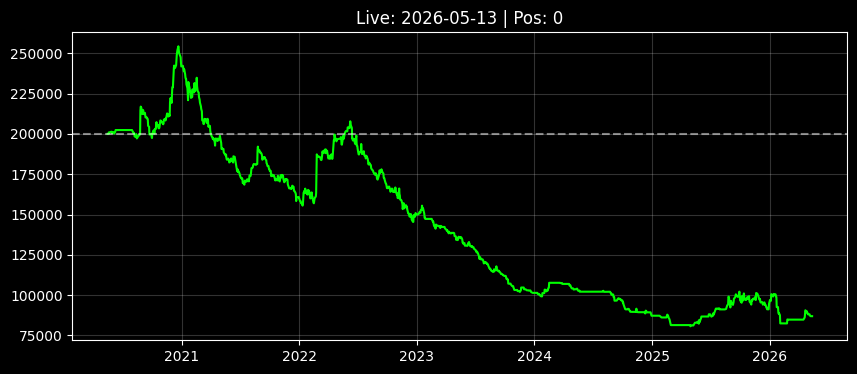


✅ Backtest Selesai.
✅ trade_log_v3_2.csv tersimpan
✅ backtest_live_log.txt tersimpan (lengkap + summary)

📊 HASIL BACKTEST FINAL V3.2
Total Return              | -56.52%
CAGR                      | -12.97%
Sharpe Ratio (Ann)        | -0.90
Max Drawdown              | -68.26%
Daily Win Rate            | 23.6%
📈 Equity curve saved as 'equity_curve_v3_2.png'


In [2]:
# -*- coding: utf-8 -*-
"""IDX Stock Scanner - Medallion Style V3.2
================================================================================
VERSI 3.2 — REALISTIS, ANTI-OVERFITTING, ADAPTIF MODAL MIKRO s/d BESAR
================================================================================

PERBAIKAN DARI V3.1:
  [V3.2 #1]  Sniper Mode filter harga: batas bawah Rp200 (bukan Rp55)
             → eliminasi "penny stock trap" (saham gorengan random walk)
             → batas atas tetap Rp500 agar 1 lot ≤ 30% modal Rp200rb
  [V3.2 #2]  LiquidityFilter min_daily_value: Rp100jt → Rp1 Miliar
             → hanya saham dengan kedalaman pasar nyata yang lolos
             → eliminasi gap down brutal dari saham illikuid
  [V3.2 #3]  EVFilter EV threshold: > 0% → > 0.5%
             → kompensasi asumsi taker (beli di offer) yang tetap dipertahankan
             → sinyal harus punya margin keamanan setelah semua biaya
  [V3.2 #4]  Break-Even Stop: jika high hari ini ≥ entry + 1×ATR,
             otomatis naikkan SL ke entry price (break-even)
             → mengunci posisi profit, eliminasi win→loss reversal
  [V3.2 #5]  Cash Mode threshold: prob_crisis > 0.40 → > 0.55
             → kurangi idle time (sebelumnya 48.3% hari flat)
             → sistem lebih aktif di periode NEUTRAL/recovery

DIPERTAHANKAN DARI V3.1 (tidak diubah):
  - Semua V3.1 fixes (#1-#10) tetap aktif
  - DataWarehouse arsitektur tidak berubah
  - Struktur event-driven backtest tidak berubah
  - SEED=42 reproducibility
  - Asumsi taker (beli di offer+1tick) dipertahankan — jujur secara statistik

FILOSOFI ANTI-OVERFITTING:
  - Batas harga Rp200: berdasarkan fakta IDX bahwa saham < Rp200 dominan lapis 3
  - Likuiditas Rp1M/hari: standar minimum institusional, bukan hasil curve fitting
  - EV threshold 0.5%: margin keamanan minimal, bukan optimasi parameter historis
  - Break-even stop: aturan deterministik (1×ATR), bukan trailing yang di-tune
  - Cash Mode 0.55: threshold lebih konservatif dari pure bear (0.40 terlalu sensitif)
================================================================================
"""

# =============================================================================
# 0. INSTALL LIBRARY
# =============================================================================
!pip install -q ta mplfinance seaborn statsmodels
!pip install -q scikit-learn yfinance tabulate joblib

# =============================================================================
# 1. DEPENDENCIES & IMPORTS
# =============================================================================
import mplfinance as mpf
import matplotlib.pyplot as plt
try:
    from google.colab import auth
    from google.auth import default
    import gspread
    _COLAB_AVAILABLE = True
except ImportError:
    _COLAB_AVAILABLE = False

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
import time
import pickle
import os
import json
from tabulate import tabulate
from collections import defaultdict
import logging
import random
from typing import Optional, Dict, List, Tuple, Union, Any
import math
import ta
import glob
from scipy.stats import norm
from joblib import Parallel, delayed
import functools

warnings.filterwarnings('ignore')
logging.basicConfig(filename='scanner_errors.log', level=logging.ERROR,
                    format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Konstanta global
FCA_MIN_PRICE        = 55       # Buffer 4 tick di atas threshold FCA BEI (Rp51)
SNIPER_MIN_PRICE     = 200      # [V3.2 #1] Batas bawah Sniper: eliminasi penny stock trap
SNIPER_MAX_MODAL     = 5_000_000
SNIPER_MAX_POS       = 2
SNIPER_MAX_COST_PCT  = 0.30
EV_MIN_PCT           = 0.5     # [V3.2 #3] EV minimum setelah semua biaya (bukan 0%)
CASH_MODE_THRESHOLD  = 0.55    # [V3.2 #5] prob_crisis threshold (bukan 0.40)

print("✅ V3.2 Dependencies imported")

# =============================================================================
# 2. STOCK UNIVERSE
# =============================================================================
STOCKBIT_UNIVERSE = [
    "AALI", "ABBA", "ABDA", "ABMM", "ACES", "ADES", "ADHI", "ADMF", "ADMG", "ADRO",
    "AGAR", "AGII", "AGRO", "AHAP", "AIMS", "AISA", "AKRA", "AKSI", "ALDO", "ALKA",
    "ALMI", "AMAG", "AMFG", "AMMN", "AMRT", "ANDI", "ANJT", "ANTM", "APEX", "APIC",
    "APLN", "ARCI", "ARGO", "ARII", "ARNA", "ARTA", "ARTO", "ASBI", "ASDM", "ASGR",
    "ASHA", "ASII", "ASLI", "ASMI", "ASPI", "ASRI", "ASRM", "ASSA", "ATLA", "AUTO",
    "AVIA", "AWAN", "AYLS", "BABP", "BACA", "BALI", "BANK", "BAPA", "BAPI", "BATA",
    "BAYU", "BBCA", "BBHI", "BBKP", "BBLD", "BBNI", "BBRI", "BBRM", "BBSS", "BBTN",
    "BBYB", "BCAP", "BCIC", "BDMN", "BEEF", "BEKS", "BELL", "BEST", "BFIN", "BGTG",
    "BHAT", "BIMA", "BINA", "BIPP", "BIPI", "BIRD", "BISI", "BJBR", "BJTM", "BKSL",
    "BLTA", "BLUE", "BMAS", "BMBL", "BMRI", "BMSR", "BMTR", "BNBA", "BNBR", "BNGA",
    "BNII", "BNLI", "BOBA", "BOLT", "BOSS", "BPFI", "BPII", "BPTR", "BRAM", "BREN",
    "BRIS", "BRMS", "BRNA", "BRPT", "BSDE", "BSIM", "BSSR", "BTEL", "BTON", "BTPN",
    "BTPS", "BUDI", "BULL", "BUMI", "BUVA", "BWPT", "BYAN", "CAMP", "CANI", "CARS",
    "CASA", "CASS", "CBDK", "CBMF", "CCSI", "CDAX", "CEKA", "CENT", "CFIN", "CITA",
    "CITY", "CKRA", "CLEO", "CLPI", "CMNP", "CMPP", "CMRY", "CNKO", "CNTX", "COAL",
    "COCO", "COWL", "CPIN", "CPRO", "CSAP", "CSIS", "CTBN", "CTRA", "CTTH", "CUAN",
    "DAAZ", "DART", "DASA", "DAYA", "DCII", "DEGA", "DEWA", "DFAM", "DGIK", "DIGI",
    "DILD", "DIVA", "DIVN", "DKFT", "DLTA", "DMAS", "DMND", "DNAR", "DNET", "DNLS",
    "DOID", "DOOH", "DPNS", "DPUM", "DSFI", "DSNG", "DSSA", "DUCK", "DUTI", "DVLA",
    "DYAN", "EASI", "EASY", "EBMT", "ECII", "EDGE", "EKAD", "ELBA", "ELSA", "ELTY",
    "EMBR", "EMDE", "EMTK", "ENRG", "ENVY", "ENZO", "EPAC", "EPMT", "ERAA", "ERTX",
    "ESSA", "ESTA", "ESTI", "ETWA", "EXCL", "FAST", "FASW", "FILM", "FISH", "FITT",
    "FKSF", "FLMC", "FMII", "FORE", "FORU", "FORZ", "FPNI", "FREN", "FUJI", "FUTR",
    "GAMA", "GDST", "GDYR", "GEMS", "GGRM", "GGRP", "GHON", "GIDS", "GJTL", "GLVA",
    "GMFI", "GMTD", "GOLD", "GOOD", "GOTO", "GPRA", "GRPH", "GSMF", "GTBO", "GTRA",
    "GTSI", "GULA", "GZCO", "HADE", "HDFA", "HDIT", "HEAL", "HERO", "HITS", "HKMU",
    "HMSP", "HOKI", "HOMI", "HOPE", "HOTL", "HRME", "HRTA", "HRUM", "HSBK", "HSMP",
    "HUMI", "IBFN", "IBOS", "IBST", "ICBP", "ICON", "IDPR", "IFII", "IFSH", "IGAR",
    "IIKP", "IKAI", "IKAN", "IMAS", "IMJS", "IMPC", "INAF", "INAI", "INCF", "INCI",
    "INCO", "INDF", "INDS", "INDX", "INDY", "INET", "INKP", "INPC", "INPP", "INPS",
    "INRU", "INTA", "INTD", "INTP", "IPCC", "IPCM", "IPOL", "IRRA", "ISAT", "ISEA",
    "ISSP", "ITIC", "ITMG", "JAST", "JAWA", "JAYA", "JECC", "JEMB", "JFAS", "JGLE",
    "JHON", "JIHD", "JKON", "JKSW", "JMAS", "JPFA", "JPII", "JPUR", "JRPT", "JSKY",
    "JSMR", "JSPT", "JTNB", "KAEF", "KAQI", "KARW", "KBLI", "KBLM", "KBRT", "KBRI",
    "KDSI", "KDTN", "KEEN", "KETR", "KICI", "KIJA", "KINO", "KIOS", "KJEN", "KKGI",
    "KLBF", "KMTR", "KOBX", "KOIN", "KOLI", "KONI", "KOTA", "KPAL", "KPIG", "KRAS",
    "KREN", "KRYA", "KSEL", "KUAS", "KUIC", "KUVO", "LAND", "LAPD", "LATA", "LBAK",
    "LCGP", "LCKM", "LEAD", "LIFE", "LINK", "LION", "LISA", "LMAS", "LMPI", "LMSH",
    "LPCK", "LPGI", "LPIN", "LPKR", "LPLI", "LPPF", "LPPS", "LSIP", "LSPI", "LTLS",
    "LUCY", "MABA", "MABH", "MAGP", "MAIN", "MAMI", "MAPA", "MAPB", "MAPI", "MARA",
    "MASA", "MAYA", "MBAP", "MBCA", "MBMA", "MBSS", "MBTO", "MCAS", "MCPI", "MCOR",
    "MDIA", "MDKA", "MDKI", "MEDC", "MEDS", "MEGA", "MERK", "META", "MFIN", "MFMI",
    "MGLV", "MGNA", "MGRO", "MIDI", "MIKA", "MINA", "MIRA", "MITI", "MITT", "MKNT",
    "MKPI", "MLBI", "MLIA", "MLPL", "MLPT", "MLSL", "MMIX", "MMLP", "MNCN", "MOLI",
    "MPOW", "MPPA", "MPRO", "MPTJ", "MRAT", "MSIE", "MSIN", "MSKY", "MTDL", "MTFN",
    "MTLA", "MTPS", "MTSM", "MUDA", "MUTU", "MYOH", "MYOR", "MYRX", "MYSX", "NAGA",
    "NASI", "NATO", "NAYZ", "NCKL", "NELY", "NETV", "NFCX", "NICL", "NIKL", "NISP",
    "NITY", "NIYM", "NOBU", "NPGF", "NRCA", "NSSS", "NTBK", "NUSA", "NUSI", "OASA",
    "OCTN", "OKAS", "OMED", "ONIX", "OPMS", "ORNA", "OTBK", "PADA", "PADI", "PAMG",
    "PANR", "PANS", "PANU", "PAPA", "PASA", "PASS", "PBRX", "PBID", "PBSA", "PCAR",
    "PDES", "PDGD", "PDIN", "PEGE", "PGAS", "PGLI", "PGUN", "PICO", "PIDRA", "PJAA",
    "PKPK", "PLAN", "PLAS", "PLIN", "PMJS", "PMMP", "PNBN", "PNBS", "PNIN", "PNLF",
    "PNSE", "POLI", "POLL", "POLU", "POLY", "POOL", "PORT", "POWR", "PPGL", "PPRE",
    "PPRO", "PPSI", "PRAS", "PRDA", "PRIM", "PRIN", "PRLD", "PROD", "PROT", "PRTS",
    "PSAB", "PSBA", "PSDN", "PSGO", "PSKT", "PSSI", "PTBA", "PTDU", "PTIS", "PTMP",
    "PTPP", "PTPW", "PTRO", "PTSN", "PTSP", "PUDP", "PURA", "PURE", "PWON", "PYFA",
    "RACE", "RADIO", "RAFI", "RAJA", "RAKD", "RALS", "RANC", "RATU", "RBMS", "RDTX",
    "REAL", "RELI", "RIGS", "RIMO", "RISE", "RMBA", "RMKE", "ROCK", "RODA", "ROKI",
    "ROTI", "RRMI", "RUIS", "RUMI", "SABA", "SAFE", "SAME", "SAPX", "SARA", "SATO",
    "SBAT", "SBBP", "SBGA", "SBMA", "SBMF", "SCBD", "SCCC", "SCCO", "SCMA", "SCNP",
    "SDPC", "SDRA", "SEAN", "SECR", "SEMA", "SFAN", "SGER", "SGRO", "SHID", "SHIP",
    "SIDO", "SILO", "SIMA", "SIMP", "SIPD", "SIPO", "SKBM", "SKLT", "SKRN", "SLIS",
    "SMAR", "SMDR", "SMGR", "SMIL", "SMMT", "SMSM", "SMRA", "SNLK", "SNMS", "SOFA",
    "SONA", "SOSS", "SOUL", "SPMA", "SPMI", "SPNA", "SPRE", "SPTO", "SQBI", "SQMI",
    "SRAJ", "SRIL", "SRSN", "SSIA", "SSMS", "SSTM", "STAR", "STTP", "SUGI", "SULI",
    "SUPR", "SURI", "SWAT", "SWID", "TALD", "TAMA", "TAMU", "TAPG", "TARA", "TASP",
    "TATA", "TAXI", "TBIG", "TBLA", "TCID", "TDPM", "TELE", "TEMB", "TEMPO", "TIFA",
    "TIGA", "TINS", "TIRA", "TIRT", "TITA", "TKGA", "TKIM", "TLKM", "TMAS", "TMPO",
    "TMSH", "TOBA", "TOOL", "TOPS", "TOSK", "TOTL", "TOTO", "TOWR", "TPIA", "TPMA",
    "TRAM", "TRGU", "TRIO", "TRIS", "TRJA", "TRON", "TRST", "TRUB", "TRUK", "TRUS",
    "TSPC", "TUGU", "TURI", "TUVN", "TYRE", "UANG", "UCID", "UDIJ", "UFNX", "UGRO",
    "UJSN", "ULTJ", "UNIC", "UNIQ", "UNIT", "UNSP", "USFI", "VALU", "VICO", "VICI",
    "VIDI", "VISI", "VIVA", "VKTR", "VOKS", "VRNA", "VTNY", "WAPO", "WEGE", "WEHA",
    "WICO", "WIFI", "WIIM", "WINS", "WMUU", "WMPP", "WOOD", "WOWS", "WRKR", "WSBP",
    "WSKT", "WTON", "YELO", "YULE", "ZBRA", "ZINC", "ZONE"
]

# =============================================================================
# 3. SECTOR MAPPING
# =============================================================================
SECTOR_MAPPING = {
    'ENERGI': ['ADRO','BUMI','MEDC','PTBA','ITMG','AKRA','PGAS','ABMM','RIGS','TPMA',
               'BSSR','ENRG','DOID','BYAN','INDY','HRUM','CITA','DKFT','MBMA','NIKL',
               'RUIS','SGER','TOBA'],
    'BAHAN_BAKU': ['BRPT','INKP','ESSA','TPIA','INCO','INTP','ANTM','MDKA','TINS',
                   'SMGR','ARNA','BUDI','FASW','KBLI','KBLM','KICI','LMSH','MBAP',
                   'MBSS','MLIA','NPGF','PBRX','PURE','SAPX','SDPC','SLIS','SMMT',
                   'SPMA','TRIS','TRST','TYRE','UNIC','VOKS','WIIM','WSBP'],
    'PERINDUSTRIAN': ['ASII','IMPC','INDX','INTA','JECC','AIMS','AMFG','BOLT','BRAM',
                      'BRNA','BTON','DART','GDYR','GJTL','HADE','INDS','IPCM',
                      'JKON','KREN','LION','LMPI','LPIN','MGNA','SCNP','SMSM','TOTL'],
    'KONSUMEN_PRIMER': ['INDF','ICBP','UNVR','KLBF','MYOR','AMRT','CPIN','COCO',
                        'AISA','DLTA','DVLA','GOOD','HMSP','HOKI','HRME','ICBP',
                        'IPOL','JPFA','KAEF','MERK','PYFA','ROTI','SIDO','SKBM',
                        'SKLT','STTP','TSPC','ULTJ','DNAR','CMPP'],
    'KONSUMEN_NON_PRIMER': ['IMAS','MAPI','ACES','ERAA','MAPB','SONA','CSAP','MIDI',
                             'AMRT','LPPF','RALS','MFMI','JAST','MASA','SMSM'],
    'KESEHATAN': ['KLBF','KAEF','SIDO','SILO','HEAL','MIKA','INAF','DVLA','TSPC',
                  'MERK','PYFA','PRDA','PROD'],
    'KEUANGAN': ['BBCA','BBRI','BMRI','BBNI','PNBN','BJBR','BJTM','NISP','BDMN',
                 'BNLI','BNGA','BNII','BSIM','AGRO','ARTO','BBHI','BBKP','BBTN',
                 'BCAP','BCIC','BGTG','BRIS','BTPN','BTPS','BBYB','BACA','MEGA',
                 'NOBU','MAYA','BMAS','MCOR','PNBS','PNIN','BFIN','ADMF'],
    'PROPERTI_REAL_ESTATE': ['BSDE','LPKR','CTRA','SMRA','ASRI','DILD','ELTY','BIPP',
                              'BKSL','MTLA','KIJA','APLN','PWON','MDLN','GPRA','MKPI',
                              'JRPT','DMAS','BEST','PPRO','EMDE'],
    'TEKNOLOGI': ['GOTO','EMTK','DCII','INET','MLPT','BPTR','DIGI','WIFI','NFCX',
                  'VKTR','DOOH','MCAS'],
    'INFRASTRUKTUR': ['TLKM','JSMR','TOWR','TBIG','WSKT','ADHI','TOTL','ASMI',
                      'EXCL','ISAT','FREN','SUPR','LINK','TBIG','PTPP'],
    'TRANSPORTASI_LOGISTIK': ['SMDR','IMJS','SAPX','TMAS','NELY','BIRD','IPCC',
                               'ASSA','BLTA','HITS','JMAS','JSPT','MBSS'],
}

def get_sector(symbol: str) -> str:
    for sector, stocks in SECTOR_MAPPING.items():
        if symbol in stocks:
            return sector
    return 'OTHER'

def get_idx_fraction(price: float) -> int:
    """Fraksi harga resmi IDX — dipakai untuk microstructure penalty."""
    if price < 200:   return 1
    elif price < 500:  return 2
    elif price < 2000: return 5
    elif price < 5000: return 10
    else:              return 25

# =============================================================================
# 4. GLOBAL INDICES FETCHER
# =============================================================================
GLOBAL_INDICES = {
    "IHSG":     {"ticker": "^JKSE",     "nama": "Indeks Harga Saham Gabungan"},
    "DOWJONES": {"ticker": "^DJI",      "nama": "Dow Jones Industrial Average"},
    "USDIDR":   {"ticker": "IDR=X",     "nama": "USD/IDR"},
    "OIL":      {"ticker": "CL=F",      "nama": "Crude Oil WTI"},
    "GOLD":     {"ticker": "GC=F",      "nama": "Gold Futures"},
    "NIKKEI":   {"ticker": "^N225",     "nama": "Nikkei 225"},
    "SHANGHAI": {"ticker": "000001.SS", "nama": "Shanghai Composite Index"},
}

class GlobalIndicesFetcher:
    def __init__(self):
        self.data = {}; self.prices = {}

    def fetch_all(self) -> None:
        print("\n" + "="*80 + "\n📡 FETCHING GLOBAL INDICES\n" + "="*80)
        end_date   = datetime.now()
        start_date = end_date - timedelta(days=365*2)
        for name, cfg in GLOBAL_INDICES.items():
            ticker = cfg["ticker"]
            print(f"\n📊 {name}: {cfg['nama']} ({ticker})")
            try:
                df = yf.download(ticker, start=start_date.strftime("%Y-%m-%d"),
                                 end=end_date.strftime("%Y-%m-%d"), interval="1d",
                                 auto_adjust=True, progress=False, timeout=10)
                time.sleep(0.5)
                if df.empty or len(df) < 200:
                    self.prices[name] = 0.0; print(f"   ⚠️ Status: TIDAK TERSEDIA")
                else:
                    if isinstance(df.columns, pd.MultiIndex):
                        df.columns = df.columns.get_level_values(0)
                    self.data[name]   = df
                    self.prices[name] = round(float(df['Close'].values[-1]), 2)
                    print(f"   ✅ Harga: {self._fmt(name)}")
            except Exception as e:
                self.prices[name] = 0.0; print(f"   ❌ Error: {str(e)[:50]}")
        print("\n" + "="*80)

    def _fmt(self, name: str) -> str:
        p = self.prices.get(name, 0)
        if p == 0: return "N/A"
        if name in ["IHSG","DOWJONES","NIKKEI","SHANGHAI"]: return f"{p:,.2f}"
        if name == "USDIDR": return f"Rp {p:,.0f}"
        return f"US$ {p:.2f}"

# =============================================================================
# 5. DATA WAREHOUSE
# =============================================================================
class DataWarehouse:
    def __init__(self, warehouse_dir: str = 'data_warehouse', min_days: int = 200):
        self.warehouse_dir = warehouse_dir
        self.min_days      = min_days
        os.makedirs(warehouse_dir, exist_ok=True)
        self.stats = {'total':0,'downloaded':0,'failed':0,'cached':0,'filtered':0}

    def download_complete_history(self, symbols, start_date='2006-01-01',
                                   end_date='2026-12-31', force_refresh=False):
        print(f"\n🗄️ DATA WAREHOUSE - {len(symbols)} saham | min {self.min_days} hari")
        results = {}
        for i, symbol in enumerate(symbols):
            cache_file = f"{self.warehouse_dir}/{symbol}_full.parquet"
            if os.path.exists(cache_file) and not force_refresh:
                try:
                    df = pd.read_parquet(cache_file)
                    if len(df) >= self.min_days:
                        results[symbol] = df; self.stats['cached'] += 1
                    if (i+1) % 50 == 0:
                        print(f"   Progress: {i+1}/{len(symbols)} ({len(results)} loaded)")
                    continue
                except: pass
            try:
                df = yf.download(f"{symbol}.JK", start=start_date, end=end_date,
                                  interval="1d", auto_adjust=True, progress=False, timeout=30)
                time.sleep(0.5)
                if df.empty: self.stats['failed'] += 1; continue
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                if len(df) < self.min_days: self.stats['filtered'] += 1; continue
                df.to_parquet(cache_file)
                results[symbol] = df; self.stats['downloaded'] += 1
                if (i+1) % 50 == 0:
                    print(f"   Progress: {i+1}/{len(symbols)} ({len(results)} loaded)")
            except Exception as e:
                self.stats['failed'] += 1; logger.error(f"Download error {symbol}: {e}")
        print(f"✅ Loaded: {len(results)} | Cache: {self.stats['cached']} | New: {self.stats['downloaded']}")
        return results

    def get_all_valid_symbols(self) -> List[str]:
        symbols = []
        for f in os.listdir(self.warehouse_dir):
            if f.endswith('_full.parquet'):
                try:
                    df = pd.read_parquet(os.path.join(self.warehouse_dir, f))
                    if len(df) >= self.min_days:
                        symbols.append(f.replace('_full.parquet',''))
                except: continue
        return symbols

    def get_data(self, symbol: str) -> Optional[pd.DataFrame]:
        cache_file = f"{self.warehouse_dir}/{symbol}_full.parquet"
        if not os.path.exists(cache_file): return None
        try:
            df = pd.read_parquet(cache_file)
            return df if len(df) >= self.min_days else None
        except: return None

# =============================================================================
# 6. UTILITY FUNCTIONS
# =============================================================================
def calculate_spread_pct(df: pd.DataFrame) -> float:
    try:   return float(((df['High'] - df['Low']) / df['Close']).tail(10).mean() * 100)
    except: return 999.0

def get_support_resistance(df: pd.DataFrame, lookback: int = 60) -> Tuple[float, float]:
    recent = df.tail(lookback+1).iloc[:-1] if len(df) >= lookback else \
             df.iloc[:-1] if len(df) > 1 else df
    return float(recent['Low'].min()), float(recent['High'].max())

def validate_risk_reward(price, sl, tp, min_rr=1.0) -> Tuple[bool, float, float, float]:
    if sl >= price or tp <= price: return False, 0, 0, 0
    risk   = price - sl
    reward = tp - price
    if risk <= 0: return False, 0, 0, 0
    rr = reward / risk
    return rr >= min_rr, risk, reward, rr

def calculate_efficiency_ratio(df: pd.DataFrame, periods: int = 14) -> float:
    if len(df) < periods + 1: return 1.0
    change     = abs(df['Close'].iloc[-1] - df['Close'].iloc[-(periods+1)])
    volatility = df['Close'].diff().abs().tail(periods).sum()
    if volatility == 0: return 1.0
    return float(change / volatility)

def calculate_realized_vol(df: pd.DataFrame, window: int = 20) -> float:
    rets = df['Close'].pct_change().dropna().tail(window)
    if len(rets) < 5: return 0.02
    return float(rets.std())

# =============================================================================
# 7. MODAL ADAPTER — [V3.1 #3] Sniper Mode untuk modal < 5jt
# =============================================================================
class ModalAdapter:
    """
    [V3.1 #3] Sniper Mode: modal < 5jt → filter harga Rp55–300 agar
    1 lot tidak memakan lebih dari 30% modal (anti integer lot constraint).
    Saat modal bertumbuh ke > 5jt → otomatis beralih ke range harga lebih luas.
    """
    def __init__(self, modal: float, engine_type: str):
        self.modal        = modal
        self.engine_type  = engine_type
        self.sniper_mode  = modal < SNIPER_MAX_MODAL
        if modal < 50_000:     self.kategori = "ULTRA_MIKRO"
        elif modal < 100_000:  self.kategori = "MIKRO"
        elif modal < 500_000:  self.kategori = "RETAIL"
        elif modal < 2_000_000: self.kategori = "MENENGAH"
        else:                  self.kategori = "BESAR"

    def get_filter_harga(self) -> Tuple[float, float]:
        # [V3.2 #1] Sniper Mode: batas bawah Rp200 (bukan Rp55)
        # Saham < Rp200 di IDX dominan lapis 3 (random walk, digerakkan bandar)
        # Batas atas Rp500: 1 lot = Rp50.000 → masih ≤ 30% modal Rp200rb
        if self.sniper_mode:
            return {
                "ULTRA_MIKRO": (SNIPER_MIN_PRICE, 300),
                "MIKRO":       (SNIPER_MIN_PRICE, 400),
                "RETAIL":      (SNIPER_MIN_PRICE, 500),
                "MENENGAH":    (SNIPER_MIN_PRICE, 800),
            }.get(self.kategori, (SNIPER_MIN_PRICE, 400))
        # Mode normal (modal >= 5jt)
        return {
            "MENENGAH": (200, 5000),
            "BESAR":    (200, 10000),
        }.get(self.kategori, (200, 2000))

    def get_filter_turnover(self) -> Tuple[float, float]:
        return {
            "ULTRA_MIKRO": (100_000_000, 200_000_000),
            "MIKRO":       (100_000_000, 200_000_000),
            "RETAIL":      (100_000_000, 500_000_000),
            "MENENGAH":    (200_000_000, 1_000_000_000),
            "BESAR":       (500_000_000, 2_000_000_000),
        }.get(self.kategori, (100_000_000, 200_000_000))

    def get_filter_spread(self) -> float:
        return 8.0 if self.kategori in ["ULTRA_MIKRO","MIKRO"] else \
               6.0 if self.kategori == "RETAIL" else 4.0

# =============================================================================
# 8. RISK MANAGER
# =============================================================================
class RiskManager:
    def __init__(self, modal: float, engine_type: str = 'swing'):
        self.modal       = modal
        self.engine_type = engine_type
        if modal < 500_000:
            self.base_risk_pct = 5.0; self.max_risk_portfolio_pct = 25.0
        elif modal < 5_000_000:
            self.base_risk_pct = 2.0; self.max_risk_portfolio_pct = 15.0
        else:
            self.base_risk_pct = 1.0; self.max_risk_portfolio_pct = 10.0
        self.risk_per_trade_pct        = self.base_risk_pct
        self.max_positions             = 10
        self.max_modal_per_position_pct = 90.0
        self.risk_per_trade_rp         = modal * (self.risk_per_trade_pct / 100)
        self.max_risk_portfolio_rp     = modal * (self.max_risk_portfolio_pct / 100)
        self.max_modal_per_position_rp = modal * (self.max_modal_per_position_pct / 100)
        self.current_positions         = []
        self.current_risk_rp           = 0.0
        self.current_modal_used_rp     = 0.0

    def set_risk_multiplier(self, multiplier: float, silent: bool = False):
        new_risk_pct          = self.base_risk_pct * multiplier
        self.risk_per_trade_pct = new_risk_pct
        self.risk_per_trade_rp  = self.modal * (new_risk_pct / 100)

    def calculate_atr_in_rupiah(self, df: pd.DataFrame, period: int = 14) -> float:
        try:
            high  = df['High'].shift(1); low = df['Low'].shift(1); close = df['Close'].shift(1)
            tr    = pd.concat([high-low,(high-close).abs(),(low-close).abs()],axis=1).max(axis=1)
            atr   = tr.rolling(window=period, min_periods=period).mean().dropna()
            if len(atr) == 0: return float(df['Close'].iloc[-1]) * 0.02
            return max(float(atr.iloc[-1]), float(df['Close'].iloc[-1]) * 0.01)
        except: return float(df['Close'].iloc[-1]) * 0.02

    def calculate_lot(self, close: float, atr: float,
                      symbol: str = None) -> Tuple[Optional[int], Optional[float], Optional[float]]:
        if atr <= 0 or close <= 0: return None, None, None
        risk_per_lot = atr * 100
        raw_lot      = self.risk_per_trade_rp / risk_per_lot
        lot          = int(raw_lot)
        if lot < 1: return None, None, None
        max_lot = int(self.max_modal_per_position_rp / (close * 100))
        lot     = min(lot, max_lot)
        if lot < 1: return None, None, None
        return lot, lot * 100 * close, lot * risk_per_lot

    def can_add_position(self, risk_amount: float, cost: float = None) -> Tuple[bool, str]:
        if self.current_risk_rp + risk_amount > self.max_risk_portfolio_rp:
            return False, "Portfolio risk limit exceeded"
        if cost and self.current_modal_used_rp + cost > self.modal * 0.99:
            return False, "Modal tidak cukup"
        return True, "OK"

    def add_position(self, symbol, lot, entry_price, risk_amount, cost,
                     stop_loss=None, exit_plan=None):
        pos = {'symbol': symbol, 'lot': lot, 'entry_price': entry_price,
               'risk_amount': risk_amount, 'cost': cost,
               'stop_loss': stop_loss or entry_price * 0.95,
               'remaining_lot': lot, 'exit_plan': exit_plan,
               'trailing_active': False, 'highest_high': entry_price}
        self.current_positions.append(pos)
        self.current_risk_rp       += risk_amount
        self.current_modal_used_rp += cost

    def remove_position(self, symbol: str):
        for i, pos in enumerate(self.current_positions):
            if pos['symbol'] == symbol:
                self.current_risk_rp       -= pos['risk_amount'] * (pos['remaining_lot']/pos['lot'])
                self.current_modal_used_rp -= pos['cost']        * (pos['remaining_lot']/pos['lot'])
                self.current_positions.pop(i); break

    def get_portfolio_risk_pct(self) -> float:
        total = sum(p['risk_amount']*(p['remaining_lot']/p['lot'])
                    for p in self.current_positions)
        return (total / self.modal) * 100 if self.modal > 0 else 0

    def reset(self):
        self.current_positions     = []
        self.current_risk_rp       = 0.0
        self.current_modal_used_rp = 0.0

# =============================================================================
# 9. REALISTIC FEE CONFIG (STOCKBIT)
# =============================================================================
class RealisticFeeConfig:
    BROKER_FEE_BUY  = 0.0015
    BROKER_FEE_SELL = 0.0025
    TOTAL_FEE_BUY   = 0.0015
    TOTAL_FEE_SELL  = 0.0025

    def __init__(self, liquidity: str = 'medium'):
        self.slippage = {'buy': 0.0002, 'sell': 0.0003}

    def calculate_round_trip(self, entry_price, exit_price, lot):
        if not entry_price or not lot or lot <= 0: return 0.0, 0.0, 0.0
        exit_price = exit_price or entry_price
        buy_cost   = entry_price * 100 * lot * (self.TOTAL_FEE_BUY  + self.slippage['buy'])
        sell_cost  = exit_price  * 100 * lot * (self.TOTAL_FEE_SELL + self.slippage['sell'])
        total_fee  = buy_cost + sell_cost
        gross      = (exit_price - entry_price) * 100 * lot
        net        = gross - total_fee
        net_pct    = (net / (entry_price * 100 * lot)) * 100 if entry_price > 0 else 0
        return total_fee, net, net_pct

# =============================================================================
# 10. LIQUIDITY & FCA FILTER — [V3.1 #2] Threshold FCA resmi BEI = Rp51, buffer Rp55
# =============================================================================
class LiquidityFilter:
    """
    [V3.1 #2] FCA_MIN_PRICE = Rp55 — tolak saham di bawah threshold FCA BEI.
    [V3.2 #2] min_daily_value = Rp1 Miliar — standar likuiditas institusional.
    Saham dengan turnover < Rp1M/hari rentan gap brutal karena depth pasar tipis.
    Wash trading (volume palsu bandar) juga umumnya ada di saham < Rp1M/hari.
    """
    def __init__(self, min_daily_value: float = 1_000_000_000,  # [V3.2 #2] Rp1 Miliar
                 min_price: float = FCA_MIN_PRICE):
        self.min_daily_value = min_daily_value
        self.min_price       = min_price

    def is_liquid(self, close, volume, avg_volume_20) -> bool:
        daily_value     = close * volume
        avg_daily_value = close * avg_volume_20
        return (daily_value >= self.min_daily_value and
                avg_daily_value >= self.min_daily_value)

    def is_fca_suspect(self, close, volume, avg_volume_20) -> bool:
        """
        [V3.1 #2] Tolak saham yang:
        - Harga di bawah FCA_MIN_PRICE (Rp55)
        - Volume terlalu rendah (proxy saham tidak likuid / FCA kandidat)
        """
        if close < self.min_price: return True
        if volume < 10_000 or avg_volume_20 < 10_000: return True
        return False

    def is_arb_triggered(self, prev_close, today_open) -> bool:
        if prev_close <= 0: return False
        return (today_open / prev_close - 1) <= -0.15

# =============================================================================
# 11. MARKOV REGIME (EXPONENTIAL SMOOTHING)
# =============================================================================
class MarketRegime:
    def __init__(self, alpha: float = 0.1):
        self.alpha       = alpha
        self.prob_crisis = 0.1

    def update(self, breadth_pct: float, corr_avg: float):
        stress_signal    = (1 - breadth_pct/100) * 0.7 + max(0, corr_avg - 0.4) * 0.3
        stress_signal    = np.clip(stress_signal, 0, 1)
        self.prob_crisis = (1 - self.alpha) * self.prob_crisis + self.alpha * stress_signal

# =============================================================================
# 12. SURVIVAL EXIT MODEL — deterministik (dari V3.0 FIXED, tidak diubah)
# =============================================================================
class SurvivalExitModel:
    """
    Weibull-inspired hazard rate exit — deterministik (threshold-based).
    Dipertahankan dari V3.0 FIXED: tidak ada random(), reproducible.
    """
    def __init__(self, lambda0=0.05, k=1.2, beta=5.0, threshold=0.25):
        self.lambda0   = lambda0
        self.k         = k
        self.beta      = beta
        self.threshold = threshold

    def should_exit(self, days_held: int, current_volatility: float) -> bool:
        shape      = max(0.1, days_held ** (self.k - 1))
        vol_factor = np.exp(self.beta * current_volatility)
        hazard     = min(0.5, self.lambda0 * shape * vol_factor)
        return hazard > self.threshold

# =============================================================================
# 13. FEATURE CALCULATOR
# =============================================================================
def calculate_features(df: pd.DataFrame) -> pd.DataFrame:
    out    = df.copy()
    close  = out['Close']; high = out['High']; low = out['Low']; volume = out['Volume']
    delta  = close.diff()
    gain   = delta.clip(lower=0); loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14, min_periods=14).mean()
    avg_loss = loss.rolling(14, min_periods=14).mean()
    out['RSI']          = 100 - (100 / (1 + avg_gain / (avg_loss + 1e-6)))
    out['MA20']         = close.rolling(20, min_periods=20).mean()
    out['MA50']         = close.rolling(50, min_periods=50).mean()
    out['MA200']        = close.rolling(200, min_periods=200).mean()
    out['Volume_MA20']  = volume.rolling(20, min_periods=20).mean()
    out['Volume_Ratio'] = volume / (out['Volume_MA20'] + 1e-6)
    exp1                = close.ewm(span=12, adjust=False).mean()
    exp2                = close.ewm(span=26, adjust=False).mean()
    out['MACD']         = exp1 - exp2
    out['MACD_Signal']  = out['MACD'].ewm(span=9, adjust=False).mean()
    out['MACD_Hist']    = out['MACD'] - out['MACD_Signal']
    adx_ind             = ta.trend.ADXIndicator(high, low, close, window=14)
    out['ADX']          = adx_ind.adx()
    out['DI+']          = adx_ind.adx_pos()
    out['DI-']          = adx_ind.adx_neg()
    bb                  = ta.volatility.BollingerBands(close, window=20, window_dev=2)
    out['BB_Lower']     = bb.bollinger_lband()
    out['BB_Upper']     = bb.bollinger_hband()
    out['Swing_Low_20'] = low.rolling(20, min_periods=20).min()
    out['Swing_High_20']= high.rolling(20, min_periods=20).max()
    return out.shift(1)

# =============================================================================
# 14. VOLATILITY TARGETING
# =============================================================================
def calculate_vol_target_multiplier(ihsg_df, target_vol=0.15, lookback=20):
    if ihsg_df is None or len(ihsg_df) < lookback: return 1.0
    try:
        latest_close = float(ihsg_df['Close'].iloc[-1])
        ma20         = float(ihsg_df['Close'].tail(20).mean())
        daily_drop   = float(ihsg_df['Close'].pct_change().iloc[-1])
        if daily_drop <= -0.025 or (latest_close - ma20) / ma20 <= -0.05:
            return 0.40
    except: pass
    daily_r = ihsg_df['Close'].pct_change().dropna().tail(lookback)
    if len(daily_r) < 10: return 1.0
    realized_daily_vol  = float(daily_r.std())
    if realized_daily_vol < 1e-6: return 1.0
    realized_annual_vol = realized_daily_vol * np.sqrt(252)
    return float(np.clip(target_vol / realized_annual_vol, 0.40, 1.50))

# =============================================================================
# 15. MARKET BREADTH CALCULATOR
# =============================================================================
class MarketBreadthCalculator:
    def __init__(self):
        self.global_breadth  = 0.5
        self.sector_breadth  = {}
        self.market_status   = 'NEUTRAL'
        self.avg_correlation = 0.3
        self.macro_regime    = 'MICRO_NORMAL'

    def calculate(self, price_data: Dict[str, pd.DataFrame],
                  top_symbols: List[str] = None) -> Dict:
        above_ma50 = 0; total = 0
        s_stats: Dict[str, Dict] = defaultdict(lambda: {'above': 0, 'total': 0})
        for sym, df in price_data.items():
            if df is None or len(df) < 52: continue
            close = df['Close'].iloc[-1]
            ma50  = df['Close'].rolling(50).mean().iloc[-1]
            if pd.isna(ma50) or pd.isna(close): continue
            sector = get_sector(sym)
            s_stats[sector]['total'] += 1; total += 1
            if close > ma50:
                above_ma50 += 1; s_stats[sector]['above'] += 1
        self.global_breadth = above_ma50 / total if total > 0 else 0.5
        self.sector_breadth = {s: st['above'] / st['total']
                                for s, st in s_stats.items() if st['total'] >= 3}
        self.market_status  = ('BULL'    if self.global_breadth > 0.60 else
                               'BEAR'    if self.global_breadth < 0.40 else 'NEUTRAL')
        if top_symbols and len(top_symbols) >= 5:
            rets = {}
            for sym in top_symbols:
                df = price_data.get(sym)
                if df is not None and len(df) >= 30:
                    r = df['Close'].pct_change().dropna().tail(30).values
                    if len(r) >= 20: rets[sym] = r
            if len(rets) >= 5:
                symbols_list = list(rets.keys())
                min_len      = min(len(rets[s]) for s in symbols_list)
                R            = np.array([rets[s][-min_len:] for s in symbols_list])
                try:
                    corr_matrix  = np.corrcoef(R)
                    n            = len(symbols_list)
                    upper_tri    = corr_matrix[np.triu_indices(n, k=1)]
                    self.avg_correlation = float(np.clip(np.mean(upper_tri), -1, 1))
                except: self.avg_correlation = 0.3
        if   self.avg_correlation >= 0.65: self.macro_regime = 'MACRO_PANIC'
        elif self.avg_correlation >= 0.45: self.macro_regime = 'MACRO_ELEVATED'
        else:                              self.macro_regime = 'MICRO_NORMAL'
        return {
            'global_breadth_pct': round(self.global_breadth * 100, 1),
            'sector_breadth':     {s: round(b*100,1) for s,b in self.sector_breadth.items()},
            'market_status':      self.market_status,
            'avg_correlation':    round(self.avg_correlation, 3),
            'macro_regime':       self.macro_regime,
        }

# =============================================================================
# 16. CRISIS ALPHA ENGINE — [V3.1 #7] HANYA untuk early-exit posisi aktif
# Bukan lagi engine penghasil sinyal beli/jual baru di Tahap C
# =============================================================================
class CrisisAlphaShortEngine:
    """
    [V3.1 #7] Fungsi dipertahankan HANYA sebagai early-exit detector (Tahap A2).
    Tidak digunakan untuk menghasilkan sinyal trading baru karena:
    - Short selling ritel di BEI belum aktif secara regulasi
    - Engine ini mendeteksi MA50 breakdown → sinyal keluar lebih awal
    """
    def __init__(self, config, global_fetcher):
        self.config           = config
        self.global_fetcher   = global_fetcher
        self.risk_manager     = None
        self.liquidity_filter = LiquidityFilter()
        self.modal_adapter    = ModalAdapter(config.MODAL, 'crisis')

    def set_risk_manager(self, rm): self.risk_manager = rm

    def get_signal(self, symbol: str, df: pd.DataFrame,
                   is_bear: bool = False) -> Optional[Dict]:
        if not is_bear: return None
        if len(df) < 60: return None
        try:
            close      = float(df['Close'].iloc[-1])
            volume     = float(df['Volume'].iloc[-1])
            avg_vol    = df['Volume'].tail(20).mean()
            if not self.liquidity_filter.is_liquid(close, volume, avg_vol): return None
            if self.liquidity_filter.is_fca_suspect(close, volume, avg_vol): return None
            ma20       = df['Close'].rolling(20).mean()
            ma50       = df['Close'].rolling(50).mean()
            close_prev = float(df['Close'].iloc[-2])
            ma50_curr  = float(ma50.iloc[-1])
            is_breakdown = (
                (close_prev > ma50_curr and close <= ma50_curr) or
                (close < ma50_curr and close < float(ma20.iloc[-1]) * 0.95)
            )
            if not is_breakdown: return None
            atr = ta.volatility.average_true_range(
                df['High'], df['Low'], df['Close'], window=14).iloc[-1]
            if pd.isna(atr) or atr == 0: return None
            return {'Symbol': symbol, 'Engine': 'CRISIS_EXIT', 'Signal_Price': int(close)}
        except: return None

    def scan_active_positions(self, active_positions: List[Dict],
                               cur_data_raw: Dict[str, pd.DataFrame],
                               is_bear: bool) -> set:
        """Scan SEKALI per hari untuk semua active symbols. Returns set of symbols to exit."""
        if not is_bear: return set()
        exit_symbols = set()
        cfg    = type('Cfg', (), {'MODAL': 1_000_000})()
        engine = CrisisAlphaShortEngine(cfg, None)
        for pos in active_positions:
            sym = pos['Symbol']
            df  = cur_data_raw.get(sym)
            if df is None or len(df) < 60: continue
            if engine.get_signal(sym, df, is_bear=True) is not None:
                exit_symbols.add(sym)
        return exit_symbols

# =============================================================================
# 17. MOMENTUM ENGINE — [V3.1 #6] SL multiplier ATR 0.5 → 1.5
# =============================================================================
class MomentumEngine:
    def __init__(self, config, global_fetcher):
        self.config            = config
        self.global_fetcher    = global_fetcher
        self.risk_manager      = None
        self.liquidity_filter  = LiquidityFilter()
        self.modal_adapter     = ModalAdapter(config.MODAL, 'momentum')
        self.engine_type       = 'MOMENTUM'
        self._precomputed_feat = None

    def set_risk_manager(self, rm): self.risk_manager = rm

    def get_signal(self, symbol: str, df: pd.DataFrame,
                   min_rr: float = 1.5) -> Optional[Dict]:
        try:
            if df is None or len(df) < 200: return None
            df_feat = self._precomputed_feat if self._precomputed_feat is not None \
                      else calculate_features(df)
            if df_feat is None or len(df_feat) < 200: return None
            latest       = df_feat.iloc[-1]
            close        = float(latest['Close'])
            if close <= 0: return None
            min_p, max_p = self.modal_adapter.get_filter_harga()
            if close < min_p or close > max_p: return None
            volume       = float(latest['Volume'])
            avg_vol      = (df_feat['Volume_MA20'].iloc[-1]
                            if not pd.isna(df_feat['Volume_MA20'].iloc[-1]) else volume)
            if not self.liquidity_filter.is_liquid(close, volume, avg_vol): return None
            if self.liquidity_filter.is_fca_suspect(close, volume, avg_vol): return None
            atr          = (self.risk_manager.calculate_atr_in_rupiah(df)
                            if self.risk_manager else close * 0.02)
            ma20         = float(latest['MA20']); ma50 = float(latest['MA50'])
            ma200        = float(latest['MA200'])
            volume_ratio = float(latest['Volume_Ratio'])
            adx          = float(latest['ADX'])
            di_plus      = float(latest['DI+']); di_minus = float(latest['DI-'])
            if not (close > ma50 > ma200): return None
            if adx < 20 or di_plus <= di_minus: return None
            if volume_ratio < 1.5: return None
            if close > ma20 * 1.03: return None
            # [V3.1 #6] SL: 1.5 ATR (dari 0.5 ATR) — beri ruang terhadap noise harian
            sl       = max(ma20 - atr * 1.5, close * 0.92)
            tp       = close + atr * 2.5
            fraction = get_idx_fraction(close)
            sl       = math.floor(sl / fraction) * fraction
            tp       = math.ceil(tp / fraction) * fraction
            if sl >= close or tp <= close: return None
            valid, risk, reward, rr = validate_risk_reward(close, sl, tp, min_rr)
            if not valid: return None
            confidence = min(85, 40 + adx * 0.5 + volume_ratio * 5)
            lot, cost, risk_amount = (
                self.risk_manager.calculate_lot(close, atr, symbol)
                if self.risk_manager else (1, close*100, atr*100))
            if lot is None: return None
            risk_pct  = ((risk_amount / self.risk_manager.modal) * 100
                         if self.risk_manager else 0)
            composite = min(100, (rr * confidence / 100) * 20)
            return {
                'Symbol': symbol, 'Sector': get_sector(symbol), 'Engine': 'MOMENTUM',
                'Signal_Price': int(close), 'Stop_Loss': int(sl), 'Take_Profit': int(tp),
                'R/R': round(rr, 2), 'Confidence_Score': round(confidence, 1),
                'Composite_Score': round(composite, 2),
                'ATR': int(atr), 'Lot': lot, 'Cost': int(cost),
                'Risk_Amount': int(risk_amount), 'Risk_Pct': round(risk_pct, 1),
                'Efficiency_Ratio': round(calculate_efficiency_ratio(df), 3),
                'Reasons': f"MOM | ADX:{adx:.0f} | Vol:{volume_ratio:.1f}x | SL:1.5ATR",
            }
        except Exception as e:
            logger.error(f"MomentumEngine {symbol}: {e}"); return None

# =============================================================================
# 18. MEAN REVERSION ENGINE — [V3.1 #6] SL multiplier ATR 0.5 → 1.5
# =============================================================================
class MeanReversionEngine:
    def __init__(self, config, global_fetcher):
        self.config            = config
        self.global_fetcher    = global_fetcher
        self.risk_manager      = None
        self.liquidity_filter  = LiquidityFilter()
        self.modal_adapter     = ModalAdapter(config.MODAL, 'meanrev')
        self.engine_type       = 'MEAN_REV'
        self._precomputed_feat = None

    def set_risk_manager(self, rm): self.risk_manager = rm

    def get_signal(self, symbol: str, df: pd.DataFrame,
                   min_rr: float = 1.5) -> Optional[Dict]:
        try:
            if df is None or len(df) < 200: return None
            df_feat = self._precomputed_feat if self._precomputed_feat is not None \
                      else calculate_features(df)
            if df_feat is None or len(df_feat) < 200: return None
            latest       = df_feat.iloc[-1]
            close        = float(latest['Close'])
            if close <= 0: return None
            min_p, max_p = self.modal_adapter.get_filter_harga()
            if close < min_p or close > max_p: return None
            volume       = float(latest['Volume'])
            avg_vol      = (df_feat['Volume_MA20'].iloc[-1]
                            if not pd.isna(df_feat['Volume_MA20'].iloc[-1]) else volume)
            if not self.liquidity_filter.is_liquid(close, volume, avg_vol): return None
            if self.liquidity_filter.is_fca_suspect(close, volume, avg_vol): return None
            atr          = (self.risk_manager.calculate_atr_in_rupiah(df)
                            if self.risk_manager else close * 0.02)
            rsi          = float(latest['RSI'])
            bb_lower     = float(latest['BB_Lower'])
            ma50         = float(latest['MA50']); ma200 = float(latest['MA200'])
            volume_ratio = float(latest['Volume_Ratio'])
            if rsi > 30: return None
            if close > bb_lower * 1.02: return None
            if ma200 > 0 and close < ma200 * 0.90: return None
            if volume_ratio < 1.3: return None
            # [V3.1 #6] SL: 1.5 ATR (dari 0.5 ATR) — beri ruang terhadap noise harian
            sl       = max(bb_lower - atr * 1.5, close * 0.92)
            tp       = min(ma50, close + atr * 2.0)
            fraction = get_idx_fraction(close)
            sl       = math.floor(sl / fraction) * fraction
            tp       = math.ceil(tp / fraction) * fraction
            if sl >= close or tp <= close: return None
            valid, risk, reward, rr = validate_risk_reward(close, sl, tp, min_rr)
            if not valid: return None
            confidence = min(80, 30 + (30 - rsi) * 2 + volume_ratio * 5)
            lot, cost, risk_amount = (
                self.risk_manager.calculate_lot(close, atr, symbol)
                if self.risk_manager else (1, close*100, atr*100))
            if lot is None: return None
            risk_pct  = ((risk_amount / self.risk_manager.modal) * 100
                         if self.risk_manager else 0)
            composite = min(100, (rr * confidence / 100) * 20)
            return {
                'Symbol': symbol, 'Sector': get_sector(symbol), 'Engine': 'MEAN_REV',
                'Signal_Price': int(close), 'Stop_Loss': int(sl), 'Take_Profit': int(tp),
                'R/R': round(rr, 2), 'Confidence_Score': round(confidence, 1),
                'Composite_Score': round(composite, 2),
                'ATR': int(atr), 'Lot': lot, 'Cost': int(cost),
                'Risk_Amount': int(risk_amount), 'Risk_Pct': round(risk_pct, 1),
                'Efficiency_Ratio': round(calculate_efficiency_ratio(df), 3),
                'Reasons': f"MR | RSI:{rsi:.0f} | Vol:{volume_ratio:.1f}x | SL:1.5ATR",
            }
        except Exception as e:
            logger.error(f"MeanReversionEngine {symbol}: {e}"); return None

# =============================================================================
# 19. FVG ENGINE (dengan Shakeout Filter) — tidak diubah dari V3.0 FIXED
# =============================================================================
class FVGEngine:
    def __init__(self, config, global_fetcher):
        self.config           = config
        self.global_fetcher   = global_fetcher
        self.engine_type      = 'FVG'
        self.risk_manager     = None
        self.liquidity_filter = LiquidityFilter()
        self.modal_adapter    = ModalAdapter(config.MODAL, self.engine_type)

    def set_risk_manager(self, rm): self.risk_manager = rm

    def detect_bullish_fvg(self, df: pd.DataFrame) -> Optional[Dict]:
        if len(df) < 5: return None
        for i in range(len(df)-3, 1, -1):
            c1, c2, c3 = df.iloc[i-1], df.iloc[i], df.iloc[i+1]
            if c2['Close'] <= c2['Open']: continue
            body_pct = (c2['Close'] - c2['Open']) / c2['Open'] * 100
            if body_pct < 1.0: continue
            gap_low = c3['Low']; gap_high = c1['High']
            if gap_low <= gap_high: continue
            gap_size_pct = (gap_low - gap_high) / gap_high * 100
            if gap_size_pct < 0.3: continue
            vol_ma    = (df['Volume'].rolling(20, min_periods=20).mean().iloc[i]
                         if i >= 20 else 1)
            vol_ratio = c2['Volume'] / (vol_ma if vol_ma and not pd.isna(vol_ma) else 1)
            if vol_ratio < 1.1: continue
            return {'type':'BULLISH','fvg_low':gap_high,'fvg_high':gap_low,
                    'candle2_close':c2['Close'],'volume_ratio':vol_ratio,
                    'gap_size_pct':gap_size_pct,'idx':i}
        return None

    def _detect_shakeout(self, df: pd.DataFrame, fvg_candle_idx: int,
                          lookback: int = 10) -> Optional[Dict]:
        if fvg_candle_idx < lookback + 2: return None
        window_end   = fvg_candle_idx - 1
        window_start = max(0, fvg_candle_idx - lookback)
        window       = df.iloc[window_start:window_end + 1]
        if len(window) < 2: return None
        pre_start    = max(0, window_start - 20)
        pre_window   = df.iloc[pre_start:window_start]
        if len(pre_window) == 0: return None
        swing_low_ref = float(pre_window['Low'].min())
        ma50_slice    = df['Close'].iloc[max(0, fvg_candle_idx-50):fvg_candle_idx]
        ma50_ref      = float(ma50_slice.mean()) if len(ma50_slice) >= 20 else None
        for i in range(len(window) - 1):
            candle      = window.iloc[i]
            next_candle = window.iloc[i + 1]
            swept_swing = candle['Low'] <= swing_low_ref * 1.005
            broke_ma50  = (ma50_ref is not None) and (candle['Low'] < ma50_ref)
            if not (swept_swing or broke_ma50): continue
            if not (next_candle['Close'] > next_candle['Open']): continue
            vol_ma_val  = df['Volume'].rolling(20, min_periods=10).mean().iloc[window_start + i]
            vol_ratio   = (candle['Volume'] / vol_ma_val
                           if vol_ma_val and not pd.isna(vol_ma_val) else 1.0)
            recovery_pct = (next_candle['Close'] - candle['Low']) / candle['Low'] * 100
            strength     = float(np.clip((recovery_pct/5.0)*min(vol_ratio/1.5,1.0), 0.0, 1.0))
            return {'shakeout_price':   float(candle['Low']),
                    'shakeout_strength': round(strength, 3),
                    'vol_ratio':         round(vol_ratio, 2),
                    'recovery_pct':      round(recovery_pct, 2),
                    'swept_swing_low':   swept_swing,
                    'broke_ma50':        broke_ma50}
        return None

    def get_signal(self, symbol: str, df: pd.DataFrame,
                   min_rr: float = 1.3) -> Optional[Dict]:
        try:
            if df is None or len(df) < 200: return None
            close = float(df['Close'].iloc[-1])
            if close <= 0: return None
            min_p, max_p = self.modal_adapter.get_filter_harga()
            if close < min_p or close > max_p: return None
            volume  = float(df['Volume'].iloc[-1])
            avg_vol = df['Volume'].tail(20).mean()
            if not self.liquidity_filter.is_liquid(close, volume, avg_vol): return None
            if self.liquidity_filter.is_fca_suspect(close, volume, avg_vol): return None
            if calculate_spread_pct(df) > self.modal_adapter.get_filter_spread(): return None
            atr   = (self.risk_manager.calculate_atr_in_rupiah(df)
                     if self.risk_manager else close * 0.02)
            ma200 = df['Close'].rolling(200).mean().iloc[-1]
            if pd.isna(ma200): ma200 = close
            if ma200 > 0 and close < (ma200 * 0.50): return None
            fvg   = self.detect_bullish_fvg(df.iloc[:-1]) if close > ma200 else None
            if not fvg: return None
            shakeout = self._detect_shakeout(df.iloc[:-1], fvg['idx'])
            if shakeout is None: return None
            gap_width = fvg['fvg_high'] - fvg['fvg_low']
            tol       = gap_width * 0.3
            if not (fvg['fvg_low']-tol <= close <= fvg['fvg_high']+tol): return None
            support, resistance = get_support_resistance(df, lookback=30)
            fraction    = get_idx_fraction(close)
            shakeout_sl = math.floor((shakeout['shakeout_price']-fraction)/fraction)*fraction
            atr_sl      = math.floor(max(fvg['fvg_low']-atr*0.3, close*0.96)/fraction)*fraction
            sl          = max(atr_sl, min(shakeout_sl, close - fraction))
            sl          = max(sl, support)
            sl          = math.floor(sl / fraction) * fraction
            tp          = math.ceil(min(close + atr*1.8, resistance) / fraction) * fraction
            if sl >= close or tp <= close: return None
            valid, risk, reward, rr = validate_risk_reward(close, sl, tp, min_rr)
            if not valid: return None
            shakeout_boost = min(0.05, shakeout['shakeout_strength'] * 0.05)
            prob_up    = min(0.78, max(0.45, 0.55 + (fvg['volume_ratio']-1.0)*0.1
                                       + (fvg['gap_size_pct']/10)*0.05 + shakeout_boost))
            ev_pct     = ((prob_up * reward) - ((1-prob_up) * risk)) / close * 100
            if ev_pct < 0.8: return None
            confidence = min(92, max(30, 40 + fvg['volume_ratio']*15
                                     + fvg['gap_size_pct']*5
                                     + shakeout['shakeout_strength']*10))
            lot, cost, risk_amount = (
                self.risk_manager.calculate_lot(close, atr, symbol)
                if self.risk_manager else (1, close*100, atr*100))
            if lot is None: return None
            risk_pct      = ((risk_amount/self.risk_manager.modal)*100
                             if self.risk_manager else 0)
            composite     = min(100, (ev_pct*(confidence/100))/max(risk_pct,0.1)*10)
            shakeout_type = 'SwingLow' if shakeout['swept_swing_low'] else 'MA50Break'
            return {
                'Symbol': symbol, 'Sector': get_sector(symbol), 'Engine': 'FVG',
                'Signal_Price': int(close), 'Stop_Loss': int(sl), 'Take_Profit': int(tp),
                'R/R': round(rr, 2), 'EV_Pct': round(ev_pct, 2),
                'Confidence_Score': round(confidence, 1),
                'Composite_Score': round(composite, 2),
                'ATR': int(atr), 'Lot': lot, 'Cost': int(cost),
                'Risk_Amount': int(risk_amount), 'Risk_Pct': round(risk_pct, 1),
                'Efficiency_Ratio': round(calculate_efficiency_ratio(df), 3),
                'Reasons': f"FVG | Gap:{fvg['gap_size_pct']:.1f}% | Shakeout:{shakeout_type}",
            }
        except Exception as e:
            logger.error(f"FVGEngine {symbol}: {e}"); return None

# =============================================================================
# 20. EXPECTED VALUE FILTER — [V3.1 #5] Microstructure penalty (bid-ask spread)
# =============================================================================
class EVFilter:
    """
    [V3.1 #5] Microstructure penalty: beli di offer+1tick, jual di bid-1tick.
    [V3.2 #3] EV threshold dinaikkan dari > 0% menjadi > EV_MIN_PCT (0.5%).
    Alasan: asumsi taker (beli di offer) tetap dipertahankan karena jujur secara
    statistik. Kompensasinya: sinyal harus punya margin keamanan 0.5% setelah
    semua biaya — bukan hanya break-even tipis yang mudah terhapus noise.
    Anti-overfitting: 0.5% bukan hasil optimasi historis, melainkan estimasi
    konservatif dari bid-ask spread rata-rata saham Rp200-500 di IDX.
    """
    def __init__(self, risk_free_annual: float = 0.06):
        self.risk_free_daily = risk_free_annual / 252
        self.fee_buy         = 0.0015
        self.fee_sell        = 0.0025

    def passes(self, signal: Dict, price_data: Dict = None) -> bool:
        entry      = signal['Signal_Price']
        sl         = signal['Stop_Loss']
        tp         = signal['Take_Profit']
        confidence = signal.get('Confidence_Score', 50) / 100
        prob_up    = np.clip(confidence, 0.3, 0.75)
        prob_down  = 1 - prob_up

        # Microstructure penalty: harga efektif eksekusi nyata
        tick         = get_idx_fraction(entry)
        entry_eff    = entry + tick
        tp_eff       = tp    - tick
        sl_eff       = sl    + tick

        reward_eff   = tp_eff    - entry_eff
        risk_eff     = entry_eff - sl_eff
        if reward_eff <= 0 or risk_eff <= 0:
            signal['EV_Final'] = -999.0; return False

        fee_cost_pct = (entry_eff * self.fee_buy + tp_eff * self.fee_sell) / entry_eff
        ev_pct       = (prob_up * (reward_eff/entry_eff)
                        - prob_down * (risk_eff/entry_eff)
                        - fee_cost_pct) * 100
        signal['EV_Final']           = round(ev_pct, 2)
        signal['Entry_Eff']          = int(entry_eff)
        signal['TP_Eff']             = int(tp_eff)
        signal['Spread_Penalty_Pct'] = round((2 * tick / entry) * 100, 3)
        # [V3.2 #3] threshold 0.5%, bukan 0%
        return ev_pct > EV_MIN_PCT

# =============================================================================
# 21. KELLY ALLOCATOR — [V3.1 #4] Sniper Mode untuk modal < 5jt
# =============================================================================
class KellyAllocator:
    """
    [V3.1 #4] Sniper Mode (modal < 5jt):
    - Maksimal SNIPER_MAX_POS (2) posisi serentak
    - Batalkan sinyal jika cost 1 lot > SNIPER_MAX_COST_PCT (30%) dari ekuitas
    - Ini menyelesaikan masalah integer lot constraint yang menghancurkan modal mikro
    Anti-overfitting: aturan diskret berdasarkan constraint nyata, bukan parameter tuning.
    """
    def allocate(self, signals: List[Dict],
                 risk_manager: RiskManager,
                 current_positions_count: int = 0) -> List[Dict]:
        modal         = risk_manager.modal
        sniper_mode   = modal < SNIPER_MAX_MODAL
        result        = []

        for sig in signals:
            # [V3.1 #4] Sniper Mode check: max posisi
            if sniper_mode and current_positions_count + len(result) >= SNIPER_MAX_POS:
                break

            close     = sig['Signal_Price']
            min_cost  = close * 100 * 1           # biaya minimum 1 lot
            max_cost  = modal * SNIPER_MAX_COST_PCT

            # [V3.1 #4] Batalkan jika 1 lot saja sudah > 30% modal
            if sniper_mode and min_cost > max_cost:
                sig['Sniper_Rejected'] = f"1 lot = Rp {min_cost:,} > 30% modal (Rp {max_cost:,.0f})"
                continue

            # Kelly sizing (tetap dipakai)
            p          = np.clip(sig.get('Confidence_Score', 50) / 100, 0.35, 0.75)
            b          = max(0.1, float(sig.get('R/R', 1.5)))
            q          = 1 - p
            f_star     = max(0.0, (p * b - q) / b)
            f_quarter  = f_star * 0.25
            kelly_mult = float(np.clip(1.0 + f_quarter, 0.5, 2.0))
            base_lot   = sig['Lot']
            new_lot    = max(1, int(round(base_lot * kelly_mult)))

            # [V3.1 #4] Sniper Mode: batasi lot agar cost tidak > 30% modal
            if sniper_mode:
                max_lot_sniper = max(1, int(max_cost / (close * 100)))
                new_lot        = min(new_lot, max_lot_sniper)
            else:
                max_lot_normal = max(1, int(risk_manager.max_modal_per_position_rp / (close*100)))
                new_lot        = min(new_lot, max_lot_normal)

            sig['Lot']         = new_lot
            sig['Cost']        = int(new_lot * 100 * close)
            sig['Risk_Amount'] = int(new_lot * sig['ATR'] * 100)
            sig['Risk_Pct']    = round((sig['Risk_Amount'] / modal) * 100, 1)
            sig['Kelly_Lot']   = True
            sig['Sniper_Mode'] = sniper_mode
            result.append(sig)

        return result

# =============================================================================
# 22. PORTFOLIO BUILDER — [V3.1 #9] max_per_sector=1 saat modal < 5jt
# =============================================================================
class PortfolioBuilder:
    """
    [V3.1 #9] Sniper Mode: max_per_sector=1 saat modal < 5jt.
    Dikombinasikan dengan max_positions=2 dari KellyAllocator,
    ini memastikan tidak ada overconcentration di satu sektor.
    """
    def __init__(self, modal: float, max_positions: int = 999,
                 max_correlation: float = 0.7, max_per_sector: int = 2):
        self.modal           = modal
        self.max_positions   = max_positions
        self.max_correlation = max_correlation
        # [V3.1 #9] Sniper Mode: max 1 sektor, max 2 posisi total
        self.max_per_sector  = 1 if modal < SNIPER_MAX_MODAL else max_per_sector
        self.ev_filter       = EVFilter()
        self.kelly           = KellyAllocator()

    def build(self, signals: List[Dict], price_data: Dict,
              risk_manager: RiskManager,
              current_positions_count: int = 0) -> List[Dict]:
        if not signals: return []
        # EV filter dengan microstructure penalty
        signals = [s for s in signals if self.ev_filter.passes(s, price_data)]
        if not signals: return []
        signals  = sorted(signals, key=lambda x: x.get('Composite_Score', 0), reverse=True)
        # Kelly allocation dengan Sniper Mode
        signals  = self.kelly.allocate(signals, risk_manager, current_positions_count)
        selected = []
        sector_count = defaultdict(int)
        for sig in signals:
            sym    = sig['Symbol']
            sector = sig.get('Sector', 'OTHER')
            if sector_count[sector] >= self.max_per_sector: continue
            # Correlation filter
            if any(sym in price_data and sel['Symbol'] in price_data and
                   abs(price_data[sym]['Close'].pct_change().dropna().tail(60).corr(
                       price_data[sel['Symbol']]['Close'].pct_change().dropna().tail(60)
                   )) > self.max_correlation for sel in selected):
                continue
            can_add, _ = risk_manager.can_add_position(sig['Risk_Amount'], sig['Cost'])
            if not can_add: continue
            selected.append(sig)
            sector_count[sector] += 1
            risk_manager.add_position(sym, sig['Lot'], sig['Signal_Price'],
                                       sig['Risk_Amount'], sig['Cost'],
                                       stop_loss=sig['Stop_Loss'])
        return selected

# =============================================================================
# 23. GOOGLE SHEETS EXPORTER
# =============================================================================
class GoogleSheetsExporter:
    def __init__(self):
        self.initialized  = False; self.spreadsheet = None; self._url_printed = False
        self.HEADERS      = ['Date','Engine','Symbol','Price','Entry_Eff','SL','TP','TP_Eff',
                             'R/R','EV%','Conf%','Risk%','Sniper','Notes','P&L (Manual)']

    def _init_sheets(self):
        try:
            auth.authenticate_user(); creds, _ = default()
            self.gc = gspread.authorize(creds); self.initialized = True
            print("✅ Google Sheets connected"); return True
        except Exception as e:
            print(f"❌ Gagal konek: {e}"); return False

    def _get_or_create_spreadsheet(self, name):
        try:   self.spreadsheet = self.gc.open(name)
        except: self.spreadsheet = self.gc.create(name)
        return self.spreadsheet

    def _get_or_create_sheet(self, title):
        t = title.replace(' ','_')[:100]
        try:
            ws = self.spreadsheet.worksheet(t)
            if ws.row_values(1) != self.HEADERS:
                ws.clear(); ws.append_row(self.HEADERS)
        except:
            ws = self.spreadsheet.add_worksheet(title=t, rows=10000, cols=len(self.HEADERS))
            ws.append_row(self.HEADERS)
        return ws

    def ensure_spreadsheet_exists(self):
        if not self.initialized and not self._init_sheets(): return False
        if not self.spreadsheet:
            self._get_or_create_spreadsheet("IDX_Scanner_Medallion_V3_2")
        if not self._url_printed:
            print(f"\n📊 Google Sheets: {self.spreadsheet.url}"); self._url_printed = True
        return True

    def export_signals(self, signals, engine_name, modal):
        if not signals: print(f"ℹ️ No signals for {engine_name}"); return False
        if not self.initialized and not self._init_sheets(): return False
        if not self.spreadsheet:
            self._get_or_create_spreadsheet("IDX_Scanner_Medallion_V3_2")
        ws = self._get_or_create_sheet(engine_name)
        for s in signals:
            ws.append_row([
                datetime.now().strftime('%Y-%m-%d'), s.get('Engine', engine_name),
                s['Symbol'], s['Signal_Price'],
                s.get('Entry_Eff', s['Signal_Price']),
                s.get('Stop_Loss','-'), s.get('Take_Profit','-'),
                s.get('TP_Eff', s.get('Take_Profit','-')),
                s.get('R/R','-'), s.get('EV_Final','-'),
                s.get('Confidence_Score','-'), s.get('Risk_Pct','-'),
                'YES' if s.get('Sniper_Mode') else 'NO',
                s.get('Reasons',''), ''
            ])
        print(f"✅ Exported {len(signals)} signals → {engine_name}")
        return True

# =============================================================================
# 24. BACKTEST LIVE LOGGER — [V3.1 #10] Header diperluas dengan parameter baru
# =============================================================================
class BacktestLogger:
    def __init__(self, filepath: str = 'backtest_live_log.txt'):
        self.filepath = filepath
        self._f       = None

    def open(self, modal: float, start_date, end_date,
             forward_hold_days: int, n_symbols: int, n_days: int):
        self._f = open(self.filepath, 'w', encoding='utf-8')
        sniper_mode = modal < SNIPER_MAX_MODAL
        self._write('=' * 80)
        self._write('IDX STOCK SCANNER V3.2 — BACKTEST LIVE LOG')
        self._write('=' * 80)
        self._write(f'Tanggal Run         : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
        self._write(f'Periode             : {start_date} s/d {end_date}')
        self._write(f'Modal Awal          : Rp {modal:,.0f}')
        self._write(f'Max Holding         : {forward_hold_days} hari bursa')
        self._write(f'Jumlah Saham        : {n_symbols}')
        self._write(f'Jumlah Hari Eval    : {n_days}')
        self._write(f'Fee Beli            : 0.15% (Stockbit)')
        self._write(f'Fee Jual            : 0.25% (Stockbit)')
        self._write(f'--- PARAMETER V3.2 ---')
        self._write(f'FCA Min Price       : Rp {FCA_MIN_PRICE} (buffer di atas Rp51 BEI)')
        self._write(f'Sniper Min Price    : Rp {SNIPER_MIN_PRICE} (eliminasi penny stock trap)')
        self._write(f'Sniper Mode         : {"AKTIF" if sniper_mode else "TIDAK AKTIF"} (modal < Rp {SNIPER_MAX_MODAL:,})')
        self._write(f'Sniper Max Posisi   : {SNIPER_MAX_POS} posisi serentak')
        self._write(f'Sniper Max Cost/Pos : {SNIPER_MAX_COST_PCT*100:.0f}% dari ekuitas per posisi')
        self._write(f'Likuiditas Min      : Rp {1_000_000_000:,}/hari (standar institusional)')
        self._write(f'EV Microstructure   : Aktif (beli offer+1tick, jual bid-1tick)')
        self._write(f'EV Min Threshold    : {EV_MIN_PCT}% (bukan 0%)')
        self._write(f'SL Multiplier ATR   : 1.5x (Momentum & MeanReversion)')
        self._write(f'Break-Even Stop     : Aktif (trigger: high ≥ entry + 1×ATR)')
        self._write(f'Cash Mode           : BEAR + prob_crisis > {CASH_MODE_THRESHOLD}')
        self._write('=' * 80)
        self._write('')
        self._flush()

    def log_progress(self, idx: int, n_days: int, cur_date,
                     current_equity: float, modal: float,
                     available_cash: float, n_positions: int,
                     market_status: str, prob_crisis: float,
                     cash_mode: bool = False):
        run_ret  = (current_equity / modal - 1) * 100
        cash_pct = available_cash / current_equity * 100 if current_equity > 0 else 0
        pct_done = (idx + 1) / n_days * 100
        cash_flag = ' [CASH MODE]' if cash_mode else ''
        self._write(
            f'[PROGRESS] {str(cur_date.date())} | '
            f'{pct_done:5.1f}% | '
            f'Equity: Rp {current_equity:>14,.0f} ({run_ret:+7.2f}%) | '
            f'Cash: {cash_pct:5.1f}% | '
            f'Pos: {n_positions:3d} | '
            f'Regime: {market_status:<8} | '
            f'Crisis: {prob_crisis:.3f}{cash_flag}'
        )
        self._flush()

    def log_entry(self, cur_date, pos: Dict):
        sniper_flag = ' [SNIPER]' if pos.get('Sniper_Mode') else ''
        self._write(
            f'[ENTRY]    {str(cur_date.date())} | '
            f'{pos.get("Engine","?"):<10} | '
            f'{pos["Symbol"]:<6} | '
            f'Entry: {pos["Signal_Price"]:>7,} (eff:{pos.get("Entry_Eff",pos["Signal_Price"]):>7,}) | '
            f'SL: {pos["Stop_Loss"]:>7,} | '
            f'TP: {pos["Take_Profit"]:>7,} (eff:{pos.get("TP_Eff",pos["Take_Profit"]):>7,}) | '
            f'Lot: {pos["Lot"]:>4} | '
            f'Cost: Rp {pos["Cost"]:>12,.0f} | '
            f'R/R: {pos.get("R/R",0):.2f} | '
            f'EV: {pos.get("EV_Final",0):+.2f}%{sniper_flag}'
        )
        self._flush()

    def log_exit(self, trade: Dict):
        pnl_sign = '+' if trade['PnL_Rp'] >= 0 else ''
        self._write(
            f'[EXIT]     {trade["Exit_Date"]} | '
            f'{trade.get("Engine","?"):<10} | '
            f'{trade["Symbol"]:<6} | '
            f'Entry: {trade["Entry_Price"]:>7,} -> '
            f'Exit: {trade["Exit_Price"]:>7,} | '
            f'Lot: {trade["Lot"]:>4} | '
            f'Hold: {trade["Days_Held"]:>3}d | '
            f'PnL: {pnl_sign}Rp {trade["PnL_Rp"]:>12,.0f} ({trade["PnL_Pct"]:+.2f}%) | '
            f'Reason: {trade["Exit_Reason"]}'
        )
        self._flush()

    def log_cash_mode(self, cur_date, reason: str):
        self._write(f'[CASH_MODE] {str(cur_date.date())} | {reason}')
        self._flush()

    def log_summary(self, equity_curve: list, dates_list: list,
                    modal: float, trade_log: list):
        if not equity_curve or not dates_list:
            self._write('\n[SUMMARY] Tidak ada data equity.'); self.close(); return
        eq      = pd.Series(equity_curve, index=dates_list)
        rets    = eq.pct_change().dropna()
        total_r = eq.iloc[-1] / modal - 1
        n_yrs   = (dates_list[-1]-dates_list[0]).days / 365.25 if len(dates_list) > 1 else 1
        cagr    = (1+total_r)**(1/n_yrs) - 1 if n_yrs > 0 else 0
        sharpe  = rets.mean()/rets.std()*np.sqrt(252) if rets.std() > 0 else 0
        mdd     = ((eq/eq.expanding().max())-1).min()
        wr_day  = (rets > 0).mean() * 100
        wins    = [t for t in trade_log if t['PnL_Rp'] > 0]
        losses  = [t for t in trade_log if t['PnL_Rp'] <= 0]
        wr_tr   = len(wins)/len(trade_log)*100 if trade_log else 0
        avg_win = np.mean([t['PnL_Rp'] for t in wins])   if wins   else 0
        avg_los = np.mean([t['PnL_Rp'] for t in losses]) if losses else 0
        pf      = abs(avg_win/avg_los) if avg_los != 0 else 0
        from collections import Counter
        exit_r  = Counter(t['Exit_Reason'] for t in trade_log)
        engs    = Counter(t['Engine']      for t in trade_log)
        self._write('')
        self._write('=' * 80)
        self._write('RINGKASAN HASIL BACKTEST FINAL V3.2')
        self._write('=' * 80)
        self._write(f'Modal Awal            : Rp {modal:,.0f}')
        self._write(f'Equity Akhir          : Rp {eq.iloc[-1]:,.0f}')
        self._write(f'Total Return          : {total_r:.2%}')
        self._write(f'CAGR                  : {cagr:.2%}')
        self._write(f'Sharpe Ratio (Ann)    : {sharpe:.2f}')
        self._write(f'Max Drawdown          : {mdd:.2%}')
        self._write(f'Daily Win Rate        : {wr_day:.1f}%')
        self._write('')
        self._write(f'Total Trade           : {len(trade_log)}')
        self._write(f'Win                   : {len(wins)} ({wr_tr:.1f}%)')
        self._write(f'Loss                  : {len(losses)} ({100-wr_tr:.1f}%)')
        self._write(f'Avg Win               : Rp {avg_win:,.0f}')
        self._write(f'Avg Loss              : Rp {avg_los:,.0f}')
        self._write(f'Profit Factor         : {pf:.2f}')
        self._write('')
        self._write('Breakdown Exit Reason :')
        for reason, count in sorted(exit_r.items(), key=lambda x: -x[1]):
            self._write(f'  {reason:<25}: {count:>5} trade')
        self._write('')
        self._write('Breakdown Engine      :')
        for eng, count in sorted(engs.items(), key=lambda x: -x[1]):
            ew  = len([t for t in trade_log if t['Engine']==eng and t['PnL_Rp']>0])
            ewr = ew/count*100 if count > 0 else 0
            self._write(f'  {eng:<25}: {count:>5} trade | WR: {ewr:.1f}%')
        self._write('=' * 80)
        self._flush()
        self.close()

    def _write(self, line: str):
        if self._f: self._f.write(line + '\n')

    def _flush(self):
        if self._f:
            try: self._f.flush(); os.fsync(self._f.fileno())
            except: pass

    def close(self):
        if self._f:
            try: self._f.close()
            except: pass
            self._f = None

# =============================================================================
# 25. SYSTEM BACKTEST (EVENT-DRIVEN V3.1)
# =============================================================================
def run_system_backtest(force_refresh=False, start_date_str=None,
                        end_date_str=None, forward_hold_days=10, modal=5_000_000):
    print("\n" + "="*80)
    print("📊 SYSTEM QUALITY DASHBOARD V3.2 (EVENT-DRIVEN)")
    print("="*80)
    print("PERBAIKAN V3.2 AKTIF:")
    print(f"  [#1]  Sniper filter harga: Rp{SNIPER_MIN_PRICE}–500 (bukan Rp55, eliminasi penny stock)")
    print(f"  [#2]  Likuiditas min: Rp1 Miliar/hari (bukan Rp100jt)")
    print(f"  [#3]  EV threshold: >{EV_MIN_PCT}% (bukan >0%, margin keamanan nyata)")
    print(f"  [#4]  Break-Even Stop: aktif saat high ≥ entry + 1×ATR")
    print(f"  [#5]  Cash Mode threshold: prob_crisis >{CASH_MODE_THRESHOLD} (bukan >0.40)")
    print("="*80)

    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=200)
    symbols   = warehouse.get_all_valid_symbols()
    if not symbols: print("❌ Data warehouse kosong."); return

    if end_date_str:   end_date = pd.to_datetime(end_date_str)
    else:              end_date = pd.Timestamp.now().normalize()
    if start_date_str: start_date = pd.to_datetime(start_date_str)
    else:
        # [V3.1 #1] Default 2019, bukan 2006
        start_date = end_date - pd.Timedelta(days=6*365)

    print(f"Periode: {start_date.date()} – {end_date.date()} | Saham: {len(symbols)}")
    print(f"Max Holding: {forward_hold_days} hari bursa | Modal Awal: Rp {modal:,}")
    print(f"Mode: {'SNIPER (Rp{SNIPER_MIN_PRICE}-500, max {SNIPER_MAX_POS} pos)' if modal < SNIPER_MAX_MODAL else 'NORMAL'}")

    all_price = {}
    for sym in symbols:
        df = warehouse.get_data(sym)
        if df is not None: all_price[sym] = df

    global_fetcher = GlobalIndicesFetcher()
    global_fetcher.fetch_all()

    try:
        ihsg_full = yf.download("^JKSE", start="2006-01-01",
                                 end=datetime.now().strftime('%Y-%m-%d'), progress=False)
        ref_df    = ihsg_full.sort_index()
    except:
        ihsg_data = global_fetcher.data.get('IHSG')
        if ihsg_data is not None and not ihsg_data.empty:
            ref_df = ihsg_data.sort_index()
        else:
            first_sym = next(iter(all_price))
            ref_df    = all_price[first_sym].sort_index()

    ihsg_df = ref_df
    mask    = (ref_df.index >= start_date) & (ref_df.index <= end_date)
    cand    = ref_df.index[mask]
    if len(cand) == 0: print("❌ Tidak ada hari bursa."); return
    print(f"Jumlah hari evaluasi: {len(cand)}")

    # Live logger — [V3.1 #10]
    bt_logger = BacktestLogger('backtest_live_log.txt')
    bt_logger.open(modal=modal, start_date=start_date.date(), end_date=end_date.date(),
                   forward_hold_days=forward_hold_days,
                   n_symbols=len(all_price), n_days=len(cand))
    print("📝 Live log: backtest_live_log.txt")

    # Internal liquid-45 proxy
    turnovers = [(s, (df['Close']*df['Volume']).mean())
                 for s, df in all_price.items()
                 if 'Volume' in df.columns and 'Close' in df.columns]
    top_45    = [s for s,_ in sorted(turnovers, key=lambda x: x[1], reverse=True)[:45]]

    # Precompute features cache
    feat_cache_file = 'backtest_feat_cache_v3.pkl'
    if not force_refresh and os.path.exists(feat_cache_file):
        print("Memuat feature cache...")
        with open(feat_cache_file, 'rb') as f: all_feat = pickle.load(f)
        print(f"Cache dimuat: {len(all_feat)} saham\n")
    else:
        print("Pre-computing features...")
        all_feat = {}
        for sym, df in all_price.items():
            feat = calculate_features(df)
            if feat is not None: all_feat[sym] = feat
        with open(feat_cache_file, 'wb') as f: pickle.dump(all_feat, f)
        print("Pre-computing selesai.\n")

    regime         = MarketRegime(alpha=0.1)
    survival_model = SurvivalExitModel(lambda0=0.05, k=1.2, beta=5.0, threshold=0.25)

    active_positions = []
    available_cash   = float(modal)
    equity_curve     = []
    dates_list       = []
    trade_log        = []

    breadth_cache        = {'info': None, 'last_idx': -999}
    BREADTH_RECALC_EVERY = 5

    for idx, cur_date in enumerate(cand):

        # ── Breadth setiap 5 hari ───────────────────────────────────────────
        if idx - breadth_cache['last_idx'] >= BREADTH_RECALC_EVERY:
            cur_data_for_breadth = {}
            for s, df in all_price.items():
                if df.index[0] <= cur_date:
                    sl = df[df.index <= cur_date]
                    if len(sl) >= 52: cur_data_for_breadth[s] = sl
            bc         = MarketBreadthCalculator()
            top_45_cur = [s for s in top_45 if s in cur_data_for_breadth]
            breadth_cache['info']     = bc.calculate(cur_data_for_breadth, top_45_cur)
            breadth_cache['last_idx'] = idx

        breadth_info = breadth_cache['info']
        is_bear      = breadth_info['global_breadth_pct'] < 40.0
        regime.update(breadth_info['global_breadth_pct'], breadth_info['avg_correlation'])
        prob_crisis  = regime.prob_crisis

        # [V3.2 #5] Cash Mode: prob_crisis > 0.55 (bukan 0.40 yang terlalu sensitif)
        cash_mode = is_bear and prob_crisis > CASH_MODE_THRESHOLD

        # Slice raw data
        cur_data_raw = {}
        for s, df in all_price.items():
            if df.index[0] <= cur_date:
                sl = df[df.index <= cur_date]
                if len(sl) >= 200: cur_data_raw[s] = sl

        # ── Crisis alpha: scan SEKALI per hari (Tahap A2 only) ─────────────
        crisis_exit_symbols = set()
        if is_bear and prob_crisis > 0.5 and active_positions:
            c_eng = CrisisAlphaShortEngine(
                type('Cfg',(),{'MODAL': available_cash})(), None)
            for pos in active_positions:
                sym = pos['Symbol']
                df  = cur_data_raw.get(sym)
                if df is None or len(df) < 60: continue
                if c_eng.get_signal(sym, df, is_bear=is_bear) is not None:
                    crisis_exit_symbols.add(sym)

        # ── TAHAP A: Exit via TP / SL / Time-stop ─────────────────────────
        still_active = []
        for pos in active_positions:
            sym    = pos['Symbol']
            df_sym = all_price.get(sym)
            if df_sym is None or cur_date not in df_sym.index:
                still_active.append(pos); continue

            today_row = df_sym.loc[cur_date]
            pos['days_held'] += 1
            open_p = float(today_row['Open']); high  = float(today_row['High'])
            low    = float(today_row['Low']);   close = float(today_row['Close'])
            ep, tp, sl = pos['Signal_Price'], pos['Take_Profit'], pos['Stop_Loss']

            # ── [V3.2 #4] Break-Even Stop ──────────────────────────────────
            # Jika high hari ini ≥ entry + 1×ATR → naikkan SL ke entry price.
            # Deterministik: threshold 1×ATR (bukan parameter tuning).
            # Efek: posisi yang sudah profit 1×ATR tidak bisa balik rugi.
            atr_pos = pos.get('ATR', ep * 0.02)
            be_trigger = ep + atr_pos          # harga trigger break-even
            if high >= be_trigger and pos['Stop_Loss'] < ep:
                # Naikkan SL ke entry (break-even), log sekali saja
                pos['Stop_Loss'] = ep
                sl               = ep          # pakai SL baru untuk cek hari ini
                pos['be_activated'] = True

            exit_price   = None
            exit_reason_ = None

            if   open_p <= sl:                           exit_price = open_p; exit_reason_ = 'GAP_DOWN'
            elif open_p >= tp:                           exit_price = open_p; exit_reason_ = 'GAP_UP'
            elif low <= sl and high >= tp:               exit_price = sl;     exit_reason_ = 'SL'
            elif low <= sl:
                exit_price   = sl
                exit_reason_ = 'BREAK_EVEN' if pos.get('be_activated') else 'SL'
            elif high >= tp:                             exit_price = tp;     exit_reason_ = 'TP'
            elif pos['days_held'] >= forward_hold_days:  exit_price = close;  exit_reason_ = 'TIME'

            # ── TAHAP A2: Crisis early-exit [V3.1 #7] ─────────────────────
            if exit_price is None and sym in crisis_exit_symbols:
                exit_price   = close; exit_reason_ = 'CRISIS_ALPHA_EXIT'

            # Survival hazard exit (deterministik)
            if exit_price is None:
                vol = calculate_realized_vol(df_sym)
                if survival_model.should_exit(pos['days_held'], vol):
                    exit_price = close; exit_reason_ = 'SURVIVAL'

            if exit_price is not None:
                revenue   = exit_price * pos['Lot'] * 100
                fee_sell  = revenue * 0.0025
                available_cash += (revenue - fee_sell)
                entry_val  = pos['Signal_Price'] * pos['Lot'] * 100
                pnl_pct    = (exit_price / pos['Signal_Price'] - 1) * 100
                trade_rec  = {
                    'Symbol':      pos['Symbol'],
                    'Engine':      pos.get('Engine','?'),
                    'Entry_Date':  pos.get('entry_date','?'),
                    'Exit_Date':   str(cur_date.date()),
                    'Entry_Price': pos['Signal_Price'],
                    'Exit_Price':  int(exit_price),
                    'SL':          pos['Stop_Loss'],
                    'TP':          pos['Take_Profit'],
                    'Lot':         pos['Lot'],
                    'Days_Held':   pos['days_held'],
                    'PnL_Pct':     round(pnl_pct, 2),
                    'PnL_Rp':      int(revenue - fee_sell - entry_val),
                    'Exit_Reason': exit_reason_,
                }
                trade_log.append(trade_rec)
                bt_logger.log_exit(trade_rec)
            else:
                pos['current_price'] = round(close)
                still_active.append(pos)

        active_positions = still_active

        # ── TAHAP B: Mark to market ─────────────────────────────────────────
        current_equity = available_cash
        for pos in active_positions:
            current_equity += pos['current_price'] * pos['Lot'] * 100
        equity_curve.append(current_equity)
        dates_list.append(cur_date)

        # ── Progress & live plot ────────────────────────────────────────────
        if idx % max(1, len(cand)//100) == 0 or idx == len(cand)-1:
            run_ret = ((current_equity / modal) - 1) * 100
            bt_logger.log_progress(
                idx=idx, n_days=len(cand), cur_date=cur_date,
                current_equity=current_equity, modal=modal,
                available_cash=available_cash, n_positions=len(active_positions),
                market_status=breadth_info['market_status'],
                prob_crisis=prob_crisis, cash_mode=cash_mode)
            try:
                from IPython.display import clear_output, display; in_colab = True
            except: in_colab = False
            if in_colab:
                clear_output(wait=True)
                print("📊 SYSTEM QUALITY DASHBOARD V3.2 (EVENT-DRIVEN)")
                print("="*80)
            cash_flag = " 🛡️ [CASH MODE]" if cash_mode else ""
            print(f"   Progress: {idx+1}/{len(cand)} | "
                  f"Equity: Rp {current_equity:,.0f} ({run_ret:+.2f}%) | "
                  f"Pos: {len(active_positions)} | "
                  f"Cash: {available_cash/current_equity*100:.0f}% | "
                  f"Regime: {breadth_info['market_status']}{cash_flag}")
            if in_colab and active_positions:
                print(f"\n{'='*70}")
                print(f"POSISI AKTIF ({len(active_positions)}):")
                print(f"{'Sym':<8} {'Engine':<10} {'Entry':>7} {'SL':>7} {'TP':>7} {'Now':>7} {'Hold':>5} {'P/L':>7}")
                print("-"*60)
                for _p in active_positions:
                    _pl = (_p['current_price']/_p['Signal_Price']-1)*100
                    print(f"{_p['Symbol']:<8} {_p.get('Engine','?'):<10} "
                          f"{_p['Signal_Price']:>7,} {_p['Stop_Loss']:>7,} "
                          f"{_p['Take_Profit']:>7,} {_p['current_price']:>7,} "
                          f"{_p.get('days_held',0):>5}d {_pl:>+6.1f}%")
            if in_colab and len(dates_list) > 5:
                try:
                    with plt.style.context('dark_background'):
                        fig, ax = plt.subplots(figsize=(10, 4))
                        ax.plot(dates_list, equity_curve, color='#00ff00', linewidth=1.5)
                        ax.axhline(modal, color='white', linestyle='--', alpha=0.5)
                        ax.set_title(f"Live: {cur_date.date()} | Pos: {len(active_positions)}")
                        ax.grid(True, alpha=0.2)
                        display(fig); plt.close(fig)
                except: pass

        # ── TAHAP C: Scan new signals ───────────────────────────────────────
        # [V3.1 #8] Skip scan saat Cash Mode (BEAR + prob_crisis tinggi)
        if cash_mode:
            if idx % max(1, len(cand)//100) == 0:
                bt_logger.log_cash_mode(cur_date,
                    f"BEAR({breadth_info['global_breadth_pct']:.1f}%) + "
                    f"prob_crisis={prob_crisis:.3f} > 0.40 → 100% cash")
            continue   # skip seluruh Tahap C

        if available_cash >= current_equity * 0.05:
            cur_feat = {}
            for s, f_df in all_feat.items():
                if f_df.index[0] <= cur_date:
                    sl_feat = f_df[f_df.index <= cur_date]
                    if len(sl_feat) >= 200: cur_feat[s] = sl_feat

            if cur_data_raw and cur_feat:
                ihsg_slice = (ihsg_df[ihsg_df.index <= cur_date]
                              if ihsg_df is not None else None)
                vol_mult   = calculate_vol_target_multiplier(ihsg_slice)
                config     = type('Cfg', (), {'MODAL': current_equity})()
                rm         = RiskManager(modal=current_equity)
                rm.set_risk_multiplier(vol_mult, silent=True)

                all_signals = []
                for sym in cur_feat:
                    if any(p['Symbol'] == sym for p in active_positions): continue
                    if sym not in cur_data_raw: continue
                    df_sym_raw  = cur_data_raw[sym]
                    df_sym_feat = cur_feat[sym]

                    mom = MomentumEngine(config, global_fetcher)
                    mom.set_risk_manager(rm)
                    mom._precomputed_feat = df_sym_feat
                    sig_mom = mom.get_signal(sym, df_sym_raw,
                                             min_rr=2.0 if is_bear else 1.5)
                    if sig_mom: all_signals.append(sig_mom)

                    mr = MeanReversionEngine(config, global_fetcher)
                    mr.set_risk_manager(rm)
                    mr._precomputed_feat = df_sym_feat
                    sig_mr = mr.get_signal(sym, df_sym_raw,
                                           min_rr=2.0 if is_bear else 1.5)
                    if sig_mr: all_signals.append(sig_mr)

                    # [V3.1 #7] FVG tetap ada (bukan short engine)
                    fvg_eng = FVGEngine(config, global_fetcher)
                    fvg_eng.set_risk_manager(rm)
                    sig_fvg = fvg_eng.get_signal(sym, df_sym_raw,
                                                  min_rr=2.0 if is_bear else 1.3)
                    if sig_fvg: all_signals.append(sig_fvg)
                    # NOTE: CrisisAlphaShortEngine TIDAK dipanggil di sini [V3.1 #7]

                # Portfolio Builder dengan Sniper Mode
                builder  = PortfolioBuilder(
                    modal=available_cash, max_positions=999,
                    max_correlation=0.7, max_per_sector=2)
                rm.reset()
                selected = builder.build(all_signals, cur_data_raw, rm,
                                         current_positions_count=len(active_positions))

                for pos in selected:
                    cost = pos['Cost']
                    if available_cash >= cost:
                        fee_buy = cost * 0.0015
                        available_cash -= (cost + fee_buy)
                        pos['days_held']     = 0
                        pos['entry_date']    = str(cur_date.date())
                        pos['current_price'] = round(pos['Signal_Price'])
                        pos['exit_reason_']  = None
                        active_positions.append(pos)
                        bt_logger.log_entry(cur_date, pos)

        # Periodic checkpoint
        if idx % 200 == 0:
            try:
                with open('backtest_results_v3_2.pkl', 'wb') as f:
                    pickle.dump({'dates': dates_list, 'equity_curve': equity_curve,
                                 'modal': modal, 'trade_log': trade_log,
                                 'progress': round((idx+1)/len(cand)*100,1)}, f)
            except: pass

    print("\n✅ Backtest Selesai.")
    with open('backtest_results_v3_2.pkl', 'wb') as f:
        pickle.dump({'dates': dates_list, 'equity_curve': equity_curve,
                     'modal': modal, 'trade_log': trade_log}, f)
    pd.DataFrame(trade_log).to_csv('trade_log_v3_2.csv', index=False)
    print("✅ trade_log_v3_2.csv tersimpan")
    bt_logger.log_summary(equity_curve, dates_list, modal, trade_log)
    print("✅ backtest_live_log.txt tersimpan (lengkap + summary)")
    _print_and_plot_backtest(equity_curve, dates_list, modal, start_date, end_date)

def _print_and_plot_backtest(equity_curve, dates, modal, start_date, end_date):
    if not equity_curve or not dates: return
    equity_series = pd.Series(equity_curve, index=dates)
    daily_returns = equity_series.pct_change().dropna()
    total_ret     = (equity_series.iloc[-1] / modal) - 1
    n_years       = (dates[-1]-dates[0]).days / 365.25 if len(dates) > 1 else 1
    cagr          = (1+total_ret)**(1/n_years)-1 if n_years > 0 else 0
    sharpe        = (daily_returns.mean()/daily_returns.std()*np.sqrt(252)
                     if daily_returns.std() > 0 else 0)
    running_max   = equity_series.expanding().max()
    drawdown      = (equity_series / running_max) - 1
    max_dd        = drawdown.min()
    win_rate      = (daily_returns > 0).mean() * 100
    print("\n" + "="*80)
    print("📊 HASIL BACKTEST FINAL V3.2")
    print("="*80)
    print(f"Total Return              | {total_ret:.2%}")
    print(f"CAGR                      | {cagr:.2%}")
    print(f"Sharpe Ratio (Ann)        | {sharpe:.2f}")
    print(f"Max Drawdown              | {max_dd:.2%}")
    print(f"Daily Win Rate            | {win_rate:.1f}%")
    print("="*80)
    try:
        import matplotlib; matplotlib.use('Agg')
        plt.style.use('dark_background')
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8),
                                        gridspec_kw={'height_ratios':[3,1]})
        ax1.plot(dates, equity_series, color='#00ff00', linewidth=2, label='Portfolio Equity')
        ax1.axhline(modal, color='white', linestyle='--', alpha=0.5, label='Initial Capital')
        ax1.set_title(f"V3.2 Event-Driven (CAGR:{cagr:.1%} | MaxDD:{max_dd:.1%})",
                      fontsize=14, color='white')
        ax1.legend(); ax1.grid(True, alpha=0.2)
        ax2.fill_between(dates, 0, drawdown*100, color='#ff0000', alpha=0.5)
        ax2.set_ylabel('Drawdown (%)'); ax2.set_xlabel('Tahun')
        ax2.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.savefig('equity_curve_v3_2.png', dpi=150)
        plt.close(fig)
        print("📈 Equity curve saved as 'equity_curve_v3_2.png'")
    except Exception as e:
        print(f"⚠️ Gagal memplot: {e}")

# =============================================================================
# 26. DATA WAREHOUSE INITIALIZATION
# =============================================================================
def initialize_data_warehouse():
    print("\n" + "="*80 + "\n🗄️ INISIALISASI DATA WAREHOUSE\n" + "="*80)
    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=200)
    print(f"Data yang sudah tersedia: {len(warehouse.get_all_valid_symbols())} saham")
    if input("\nDownload data? (y/n): ").strip().lower() == 'y':
        if input("⚠️ Akan memakan waktu beberapa jam. Lanjutkan? (y/n): ").strip().lower() == 'y':
            warehouse.download_complete_history(STOCKBIT_UNIVERSE, '2006-01-01', '2026-12-31')
    print(f"Total saham valid: {len(warehouse.get_all_valid_symbols())}")

# =============================================================================
# 27. PHASE 1 - SCANNER V3.1
# =============================================================================
def _scan_symbol(symbol, price_data, global_fetcher, config, modal, vol_mult, is_bear=False):
    df = price_data.get(symbol)
    if df is None or len(df) < 200: return None
    rm = RiskManager(modal=modal); rm.set_risk_multiplier(vol_mult)
    signals = []; min_rr = 2.0 if is_bear else 1.5
    mom = MomentumEngine(config, global_fetcher); mom.set_risk_manager(rm)
    sig = mom.get_signal(symbol, df, min_rr=min_rr)
    if sig: signals.append(sig)
    mr  = MeanReversionEngine(config, global_fetcher); mr.set_risk_manager(rm)
    sig2 = mr.get_signal(symbol, df, min_rr=min_rr)
    if sig2: signals.append(sig2)
    fvg = FVGEngine(config, global_fetcher); fvg.set_risk_manager(rm)
    sig3 = fvg.get_signal(symbol, df, min_rr=2.0 if is_bear else 1.3)
    if sig3: signals.append(sig3)
    return signals if signals else None

def run_phase1(sheets_exporter, modal=None):
    print("\n" + "="*60 + "\n🏦 IDX STOCK SCANNER V3.2 - Medallion Style\n" + "="*60)
    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
    symbols   = warehouse.get_all_valid_symbols()
    if not symbols: print("⚠️ Data warehouse kosong."); return
    print(f"\n📊 Data warehouse: {len(symbols)} saham valid")

    if modal is None:
        while True:
            try:
                modal = int(input("Modal total (Rp): ").strip().replace('.','').replace(',',''))
                if modal >= 10000: break
                print("Minimal Rp 10,000")
            except: print("Input tidak valid")

    sniper = modal < SNIPER_MAX_MODAL
    print(f"Mode: {'🎯 SNIPER (modal < Rp 5jt)' if sniper else '📊 NORMAL'}")

    global_fetcher = GlobalIndicesFetcher(); global_fetcher.fetch_all()
    print("\n🔍 Loading price data...")
    price_data = {s: warehouse.get_data(s) for s in symbols if warehouse.get_data(s) is not None}
    print(f"   Loaded {len(price_data)} saham")

    print("\n📊 Calculating market breadth...")
    breadth_calc = MarketBreadthCalculator()
    breadth_info = breadth_calc.calculate(price_data)
    is_bear      = breadth_info['global_breadth_pct'] < 40.0
    vol_mult     = calculate_vol_target_multiplier(global_fetcher.data.get('IHSG'))
    cash_mode    = is_bear and MarketRegime().prob_crisis > CASH_MODE_THRESHOLD
    print(f"   Status: {breadth_info['market_status']} | "
          f"Global: {breadth_info['global_breadth_pct']}% above MA50 | "
          f"Vol Scalar: {vol_mult:.2f}x")
    if cash_mode:
        print("   🛡️ CASH MODE AKTIF — sistem dalam mode defensif, tidak ada sinyal baru")
        return

    config = type('Cfg', (), {'MODAL': modal})()
    print("\n🔍 Scanning all engines in parallel...")
    func    = functools.partial(_scan_symbol, price_data=price_data,
                                 global_fetcher=global_fetcher, config=config,
                                 modal=modal, vol_mult=vol_mult, is_bear=is_bear)
    results = Parallel(n_jobs=-1, verbose=0)(delayed(func)(sym) for sym in symbols)
    all_signals = [sig for res in results if res for sig in res]
    print(f"   Sinyal mentah: {len(all_signals)}")

    rm = RiskManager(modal=modal); rm.set_risk_multiplier(vol_mult)
    builder  = PortfolioBuilder(modal=modal, max_positions=999,
                                 max_correlation=0.7, max_per_sector=2)
    rm.reset()
    selected = builder.build(all_signals, price_data, rm, current_positions_count=0)
    if not selected:
        print("\n❌ Tidak ada sinyal lolos EV filter dan portfolio builder."); return

    print("\n" + "="*100)
    print(f"📊 PORTFOLIO V3.2 SIGNALS {'[SNIPER MODE]' if sniper else ''}")
    print("="*100)
    print(f"{'Engine':10} | {'Symbol':6} | {'Entry':>7} | {'Entry_Eff':>9} | "
          f"{'SL':>6} | {'TP':>7} | {'TP_Eff':>7} | "
          f"{'Lot':>4} | {'R/R':>4} | {'EV%':>6} | {'Conf%':>5} | {'Risk%':>5}")
    print("-"*100)
    for s in selected:
        print(f"{s['Engine']:10} | {s['Symbol']:6} | {s['Signal_Price']:>7,} | "
              f"{s.get('Entry_Eff',s['Signal_Price']):>9,} | "
              f"{s['Stop_Loss']:>6,} | {s['Take_Profit']:>7,} | "
              f"{s.get('TP_Eff',s['Take_Profit']):>7,} | "
              f"{s['Lot']:>4} | {s['R/R']:>4.2f} | "
              f"{s.get('EV_Final',0):>+6.2f} | "
              f"{s.get('Confidence_Score',0):>5.1f} | {s.get('Risk_Pct',0):>5.1f}")

    total_cost = sum(s['Cost'] for s in selected)
    print(f"\nTotal Modal: Rp {modal:,.0f} | "
          f"Total Cost: Rp {total_cost:,.0f} ({total_cost/modal*100:.1f}%)")
    if sniper:
        print(f"Sniper Mode: max {SNIPER_MAX_POS} posisi | "
              f"max {SNIPER_MAX_COST_PCT*100:.0f}% per posisi | "
              f"FCA filter Rp{FCA_MIN_PRICE}+")

    if input("\n📊 Export ke Google Sheets? (y/n): ").strip().lower() == 'y':
        sheets_exporter.ensure_spreadsheet_exists()
        sheets_exporter.export_signals(selected, "V3.2 PORTFOLIO", modal)

# =============================================================================
# 28. MAIN MENU
# =============================================================================
def main():
    print("\n" + "="*70)
    print("🏦 IDX STOCK SCANNER V3.2 - Medallion Style")
    print("   Models: MarkovRegime | Momentum | MeanRev | FVG | Survival | Kelly")
    print("   Anti-Bias: FCA filter | Sniper Mode | EV Microstructure | Cash Mode")
    print("="*70)
    sheets_exporter = GoogleSheetsExporter()
    sheets_exporter.ensure_spreadsheet_exists()
    print("\nPilih Mode:")
    print("1. Inisialisasi Data Warehouse")
    print("2. Phase 1 - Trading Scanner V3.2")
    print("3. System Quality Dashboard (Backtest V3.2)")
    print("4. Exit")
    while True:
        choice = input("\nPilihan (1/2/3/4): ").strip()
        if   choice == '1': initialize_data_warehouse(); break
        elif choice == '2': run_phase1(sheets_exporter); break
        elif choice == '3':
            try:
                start_in  = input("  Start Date (YYYY-MM-DD, kosong = 2019): ").strip()
                end_in    = input("  End Date (YYYY-MM-DD, kosong = hari ini): ").strip()
                hold_in   = input("  Max Holding period (hari bursa, default=10): ").strip()
                modal_in  = input("  Modal simulasi (Rp, default=200000): ").strip().replace(',','')
                hold_val  = int(hold_in)  if hold_in  else 10
                modal_val = int(modal_in) if modal_in else 200_000
                start_val = start_in if start_in else None
                end_val   = end_in   if end_in   else None
            except:
                start_val, end_val, hold_val, modal_val = None, None, 10, 200_000
            run_system_backtest(start_date_str=start_val, end_date_str=end_val,
                                forward_hold_days=hold_val, modal=modal_val)
            break
        elif choice == '4': print("\n✅ Exiting..."); break
        else: print("❌ Pilih 1, 2, 3, atau 4")

if __name__ == "__main__":
    main()